# Анализ оттока клиентов банка "Метанпром"

**Заказчик:** Отдел маркетинга банка "Метанпром"

**Цель:** проанализировать клиентов банка "Метанпром" и выделить сегменты клиентов, склонных уходить из банка, для отдела маркетинга.

**Задачи:**
- проанализировать влияние признаков на отток клиентов;
- выявить закономерности оттока клиентов;
- сформулировать и проверить гипотезы;
- произвести сегментацию пользователей и приоритизировать сегменты;
- дать отделу маркетинга рекомендации о том, на каких клиентов обратить внимание в первую очередь.

**Описание данных:** Заказчик предоставил нам файл `https://code.s3.yandex.net/datasets/` c данными о клиентах банка, где была пердоставлена информация о баллах кредитного скоринга, городе проживания, поле, возрасте, баллах собственности, балансе, количестве используемых продуктов, наличии кредитной карты, активности, оценочном доходе и оттоке.

В датафрейме представлены следующие поля:
- `score` — баллы кредитного скоринга,
- `city` — город,
- `gender` — пол,
- `age` — возраст,
- `equity` — количество баллов собственности
- `balance` — баланс на счёте,
- `products` — количество продуктов, которыми пользуется клиент,
- `credit_card` — есть ли кредитная карта,
- `last_activity` — активный клиент,
- `EST_SALARY` — оценочный доход клиента,
- `сhurn` — признак оттока.

**Декомпозиция проекта:**
1. Произвести загрузку исходных данных
2. Изучить исходные данные:
   - посмотреть данные в датафрейме;
   - вывести размер датафрейма;
   - посмотреть общую информацию о датафрейме;
   - проверить статистические данные;
   - проверить наличие пропусков в данных;
   - проверить данные на наличие дубликатов - явных и неявных;
   - сопоставить типы данных в колонках;
   - проверить количественные данные на наличие аномалий;
   - проверить категоральные колонки
   
   
3. Предобработка данных:
   - обработать пропуски при их наличии;
   - заменить типы данных в колонках при необходимости;
   - обработать дубликаты при наличии;
   - обработать аномальные значения при наличии
   
   
4. Исследовательский анализ данных
   - посмотреть средние значения признаков клиентов, которые остались и попали в отток;
   - построить распределения признаков для отточных и оставшихся клиентов;
   - построить матрицу корреляций признаков и определить влияние признаков на отток;
   - сформировать общий портрет отточного клиента
   
   
5. Формулирование и проверка гипотез
   - проверить гипотезу о различия дохода между ушедшими и оставшимися клиентами банка;
   - сформулировать еще хотя бы одну (желательно несколько) гипотез на основании инсайтов, полученных в ходе исследовательского анализа
   
   
6. Сегментация клиентов
   - выделить и описать несколько сегментов клиентов банка на основе инсайтов, полученных в исследовательском анализе;
   - произвести приоритизацию сегментов
   
   
7. Выводы и рекомендации для отдела маркетинга

Ссылка на презентацию: https://disk.yandex.ru/i/3vDJsxgswj7Y6g

## Загрузка данных

Загрузим данные и посмотрим на общую информацию о датафрейме.

In [1]:
#импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import math as mth
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
#произведем загрузку файлов
try:
    bank = pd.read_csv('/datasets/bank_scrooge.csv')
except:
    bank = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv')

In [3]:
#напишем функцию для изучения данных датафрейма
"""Данная функция поможет нам изучить датафрейм.
   Функция выведет 5 первых строк датафрейма,
   его размер, общую информацию о датафрейме,
   выведет статистические данные,
   покажет наличие пропусков и явных дубликатов."""

def show_info(df):
    print('Первые 5 строк датафрейма:')
    print('-'*80)
    display(df.head())
    print('-'*80)
    print('Размер датафрейма:')
    print('-'*80)
    display(df.shape)
    print('-'*80)
    print('Общая информация о датафрейме:')
    print('-'*80)
    display(df.info())
    print('-'*80)
    print('Статистические данные:')
    print('-'*80)
    display(round(df.describe()))
    print('-'*80)
    print('Наличие пропусков в датафрейме:')
    print('-'*80)
    display(df.isna().sum())
    print('-'*80)
    print('Наличие дубликатов: {}'.format(df.duplicated().sum()))

In [4]:
#выведем необходимую информацию о датафрейме с помощью нашей функции
show_info(bank)

Первые 5 строк датафрейма:
--------------------------------------------------------------------------------


,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,"59,214.82",2,0,1,"75,719.14",1
1,146556,861.00,Рыбинск,Ж,37.00,5,"850,594.33",3,1,0,"86,621.77",0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,"107,683.34",0
3,225363,866.00,Ярославль,Ж,51.00,5,"1,524,746.26",2,0,1,"174,423.53",1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,"67,353.16",1


--------------------------------------------------------------------------------
Размер датафрейма:
--------------------------------------------------------------------------------


(10000, 12)

--------------------------------------------------------------------------------
Общая информация о датафрейме:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


...

--------------------------------------------------------------------------------
Статистические данные:
--------------------------------------------------------------------------------


,USERID,score,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
count,"10,000.00","10,000.00","9,974.00","10,000.00","7,705.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"171,815.00",849.00,43.00,3.00,"827,794.00",2.00,1.00,1.00,"147,867.00",0.00
std,"33,708.00",65.00,12.00,2.00,"1,980,614.00",1.00,0.00,0.00,"139,389.00",0.00
min,"94,561.00",642.00,18.00,0.00,0.00,0.00,0.00,0.00,"2,546.00",0.00
25%,"142,810.00",802.00,33.00,0.00,"295,554.00",1.00,0.00,0.00,"75,252.00",0.00
50%,"172,728.00",853.00,40.00,3.00,"524,272.00",2.00,1.00,1.00,"119,658.00",0.00
75%,"201,262.00",900.00,51.00,4.00,"980,706.00",2.00,1.00,1.00,"174,501.00",0.00
max,"229,145.00","1,000.00",86.00,9.00,"119,113,552.00",5.00,1.00,1.00,"1,395,064.00",1.00


--------------------------------------------------------------------------------
Наличие пропусков в датафрейме:
--------------------------------------------------------------------------------


USERID              0
score               0
city                0
gender              0
age                26
equity              0
balance          2295
products            0
credit_card         0
last_activity       0
EST_SALARY          0
churn               0
dtype: int64

--------------------------------------------------------------------------------
Наличие дубликатов: 0


**Что можем сказать о данных:**
- На первый взгляд видим, что названия колонок `USERID` и `EST_SALARY` не соответствуют ожидаемым. В дальнейшем приведем их к нижнему регистру, а колонку `USERID` к виду `user_id`.
- В датафрейме 10000 строк и 12 столбцов.
- Тип данных в колонках `score` и `age` не соответствует ожидаемому. Необходимо перевести их из типа с плавающей запятой, к целочисленному.
- В колонках `balance` и `EST_SALARY` могут быть выбросы, так как в статистических данных видим достаточное различие между средним и медианой. Стоит их проверить на наличие выбросов.
- В колонке `age` наблюдаем 26 пропусков, а в колонке `balance` - 2295 пропусков.
- Явных полных дубликатов в данных не обнаружено.
- Баллы кредитного скоринга распределены у клиентов от 642 до 1000
- Минимальный возраст клиентов 18 лет, максимальный - 86
- Количество баллов собственности варьируется в пределах от 0 до 9
- Минимальный баланс 0, максимальный - 119113552. Тут стоит проверить на наличие выбросов.
- Количество продуктов находится в пределах от 0 до 5. Уточнив у заказчика, мы узнали, что, если пользователь является клиентом банка, то он точно использует хотя бы 1 продукт. Соответственно продуктов в количестве 0 быть не может. В следующем шаге посмотрим, сколько таких клиентов в датасете и решим, что с ними делать.
- В стобце с наличием кредитной карты всего 2 значения: 0 - нет карты, 1 - кредитная карта есть.
- В столбце с активностью также 2 значения: 0 - не активен, 1 - активен (были операции в течение 30 дней).
- В столбце с оценочным доходом видим вариацию от 2546 до 1395064. Очень похоже, что в столбце есть аномальные значения.
- В столбце с оттоком 2 значения: 0 - оставшийся клиент, 1 - отточный.

## Предобработка данных

### Обработка названий столбцов

Для более цдобной работы приведем названия столбцов к нижнему регистру и название столбца с идентификаторами пользователей к виду `user_id`.

In [5]:
#приводим названия колонок к нижнему регистру
bank.columns = bank.columns.str.lower()
#приведем название столбца с идентификаторами пользователей к нужному виду
bank = bank.rename(columns={'userid': 'user_id'})
#проверяем
bank.columns

Index(['user_id', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

Все получилось! Теперь с названиями столбцов будет удобно работать.

### Обработка пропусков

В предыдущем шаге мы выяснили, что пропуски имеются в двух столбцах: `age` и `balance`.

В столбце `age` 26 пропусков, а в столбце `balance` - 2295. Посмотрим сколько это в процентном отношении к общему размеру датафрейма.

In [6]:
#считаем процентное соотношение пропусков по столбцу age
print(f'Пропусков по столбцу age в данных {26 / len(bank) * 100}%.')
#считаем процентное соотношение пропусков по столбцу balance
print(f'Пропусков по столбцу balance в данных {2295 / len(bank) * 100}%.')

Пропусков по столбцу age в данных 0.26%.
Пропусков по столбцу balance в данных 22.95%.


В столбце `age` всего 0,26% пропусков. Это совсем мало. А вот в столбце `balance` целых 22,95% пропусков по отношению ко всему датафрейму. Это достаточно много. 

Посмотрим есть ли зависимость пропусков от каких-либо признаков и после этого решим, что с ними делать.

In [7]:
#создадим копию датасета
bank_copy = bank.copy()

Создадим в копированном датасете 2 новых признака `age_gap` и `balance_gap`, где напротив пропусков в столбце с соответствующим признаком будет стоять 1, а в случае наличия значения - 0.

Добавляем новые признаки в копированный датафрейм.

In [8]:
bank_copy['age_gap'] = np.where(bank_copy['age'].isnull(), 1,0)
bank_copy['balance_gap'] = np.where(bank_copy['balance'].isnull(), 1,0)

In [9]:
#выведем первые 10 строк для проверки
bank_copy.head(10)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,age_gap,balance_gap
0,183012,850.00,Рыбинск,Ж,25.00,1,"59,214.82",2,0,1,"75,719.14",1,0,0
1,146556,861.00,Рыбинск,Ж,37.00,5,"850,594.33",3,1,0,"86,621.77",0,0,0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,"107,683.34",0,0,1
3,225363,866.00,Ярославль,Ж,51.00,5,"1,524,746.26",2,0,1,"174,423.53",1,0,0
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,"67,353.16",1,0,0
5,202305,856.00,Рыбинск,М,56.00,4,"863,687.24",3,1,0,"156,619.80",0,0,0
6,177259,807.00,Ярославль,Ж,39.00,3,"405,042.44",3,0,1,"103,838.32",0,0,0
7,218868,825.00,Ярославль,Ж,38.00,4,"458,145.40",2,1,1,"68,085.48",0,0,0
8,211686,923.00,Ярославль,М,54.00,5,"1,206,337.87",2,1,0,"155,371.79",0,0,0
9,133130,906.00,Ярославль,Ж,67.00,0,NaN,1,0,1,"238,055.53",0,0,1


Теперь посмотрим взаимосвязи пропусков от признаков на основании матрицы корреляции.

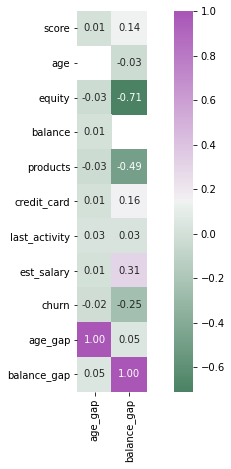

In [10]:
#рассчитываем корреляцию
gaps = bank_copy.drop(columns='user_id').corr()

#строим матрицу
plt.figure(figsize=(10, 7))
sns.heatmap(gaps[['age_gap', 'balance_gap']], annot=True, square=True, fmt='.2f', cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True))
plt.show()

На основе матрицы корреляций можно сказать, что пропуски в столбце с возрастом вообще не зависят от признаков. Об этом нам говорят коэффициенты корреляции примерно равные 0 у всех признаков, что по шкале Чеддока говорит об отсутствии взаимосвязи.

В столбце с балансом видим, что есть зависимость от признака quity (баллы собственности) на уровне коэффициента корреляции -0,71. По шкале Чеддока такой коэффициент говорит о высокой отрицательной зависимости двух признаков. Также видим умеренную отрицательную зависимость пропусков в балансе от количества продуктов (products) на уровне коэффициента корреляции равного -0,49. Так как есть явная зависимость пропусков в столбце `balance` от двух признаков, отнесем их к группе MNAR (отсутствуют не случайно), такие пропуски нельзя безобосновательно удалять или заполнять одним значением, так как это приведет к заметным искажениям. 

Поскольку пропуски в столбце `age` не имеют взаимосвязи с другими признаками, скорее всего они появились случайно. Отнесем такие пропуски к группе MCAR (отсутствуют совершенно случайно). Так как заполнение таких пропусков не повлияет на характер связи между заполняемой переменной и остальными, можем от них избавиться .Ранее мы рассчитали, что таких пропусков всего 0,26% от общего количества данных, это совсем мало и не повлияет на результат.

Посмотрим подробнее, что же делать с пропусками в балансе. Попробуем доказать, что заполнение таких пропусков приведет к искажениям.

Посмотрим распределение признака equity для клиентов с пропусками и без по балансу.

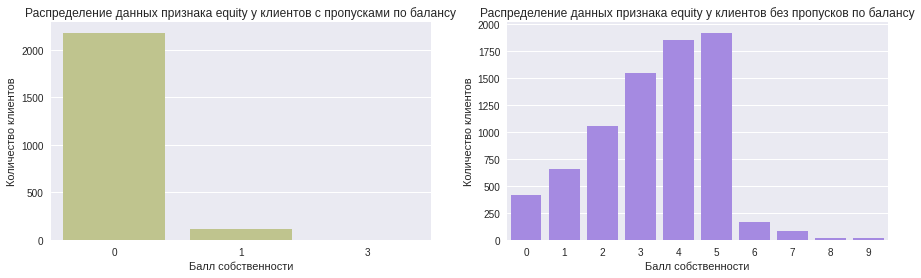

In [11]:
plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака equity для клиентов с пропусками по балансу
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=bank_copy.query('balance_gap == 1'), x='equity', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака equity у клиентов с пропусками по балансу")
plt.ylabel('Количество клиентов')
plt.xlabel('Балл собственности')

#строим гистограмму с распределением признака equity для клиентов без пропусков по балансу
ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=bank_copy.query('balance_gap == 0'), x='equity', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака equity у клиентов без пропусков по балансу")
plt.ylabel('Количество клиентов')
plt.xlabel('Балл собственности')

plt.show()

Можем наблюдать, что среди клиентов с пропусками по балансу присутствуют в основном клиенты с баллом собственности 0, и немного клиентов с баллом собственности 1.

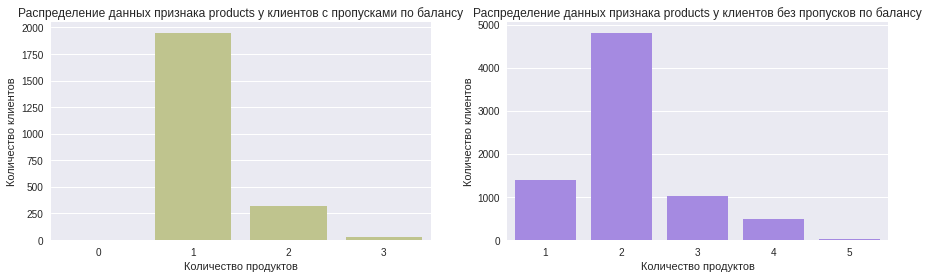

In [12]:
plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака products для клиентов с пропусками по балансу
ax1 = plt.subplot(1, 2, 1)
sns.countplot(data=bank_copy.query('balance_gap == 1'), x='products', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака products у клиентов с пропусками по балансу")
plt.ylabel('Количество клиентов')
plt.xlabel('Количество продуктов')

#строим гистограмму с распределением признака equity для клиентов без пропусков по балансу
ax2 = plt.subplot(1, 2, 2)
sns.countplot(data=bank_copy.query('balance_gap == 0'), x='products', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака products у клиентов без пропусков по балансу")
plt.ylabel('Количество клиентов')
plt.xlabel('Количество продуктов')

plt.show()

Клиенты с пропусками в балансе чаще всего имеют 1 продукт, реже 2, и очень редко 3.

Исходя из проведенного наблюдения, можно сказать, что в основном клиенты с пропусками по балансу имеют балл собствености 0 и пользуются 1 продуктом.

Можно предположить, что можно заполнить пропуски медианным значением баланса по всем клиентам с такими же показателями. Расчитаем медиану баланса (так как она устойчива к выбросам) по данному срезу клиентов и посмотрим как меняется распределение признака до и после заполнения пропусков.

In [13]:
#делаем срез клиентов с баллом собственности 0 и 1 продуктом 
clients_query = bank_copy.query('equity == 0 and products == 1')
#рассчитываем медиану
gap_median = clients_query['balance'].median()
#выводим
print(f'Медианный баланс у клиентов с баллом собственности 0 и одним продуктом составляет - {gap_median} рублей')

Медианный баланс у клиентов с баллом собственности 0 и одним продуктом составляет - 127337.41 рублей


Теперь заполним этим значением пропуски в балансе в копированном датасете.

In [14]:
#заменяем пропуски медианой
bank_copy['balance'] = bank_copy['balance'].fillna(gap_median)
#проверяем
print(bank_copy.isna().sum())

user_id           0
score             0
city              0
gender            0
age              26
equity            0
balance           0
products          0
credit_card       0
last_activity     0
est_salary        0
churn             0
age_gap           0
balance_gap       0
dtype: int64


Успешно!

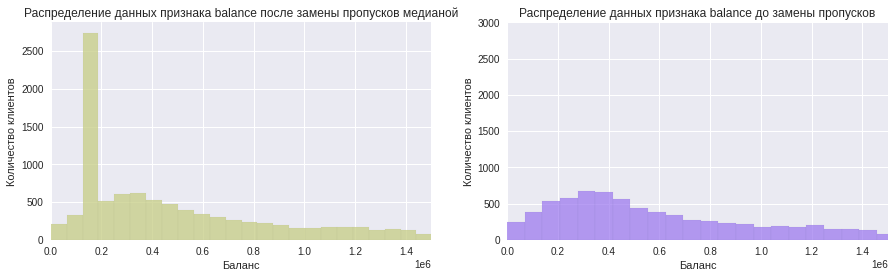

In [15]:
plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением баланса после замены пропусков
ax1 = plt.subplot(1, 2, 1)
sns.histplot(bank_copy, x='balance', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака balance после замены пропусков медианой")
plt.xlim(0, 1500000)
plt.ylabel('Количество клиентов')
plt.xlabel('Баланс')

#строим гистограмму с распределением баланса до замены пропусков
ax2 = plt.subplot(1, 2, 2)
sns.histplot(bank, x='balance', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака balance до замены пропусков")
plt.xlim(0, 1500000)
plt.ylim(0, 3000)
plt.ylabel('Количество клиентов')
plt.xlabel('Баланс')

plt.show()

На графиках наглядно видим, как изменилось распределение признака balance после замены пропусков медианным балансом. Видим всплеск с медианным балансом в области 127 тыс. рублей. Замена пропусков медианным значением нецелесообразна, так как мы получаем 22,95% искусственнных данных в столбце с балансом, что сильно влияет на распределение признака и исказит нам результаты в дальнейшем.

Можно предположительно осуществить замену пропусков средним значением по балансу, но среднее не устойчиво к выбросам, применять данную замену нецелесообразно.

Также можно было бы предположить, что пропуски в балансе означают, что на балансе у клиента 0 рублей и заменить соответствующим значением.

Посмотрим клиентов с нулевым балансом.

In [16]:
bank.query('balance == 0')

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
3900,179831,730.00,Ярославль,М,18.00,0,0.00,2,1,1,"64,548.33",0
6757,148456,813.00,Ярославль,М,20.00,2,0.00,2,1,0,"23,876.51",0


Таких клиентов всего 2. Это ничтожно мало, чтобы уловить взаимосвязь признаков и нулевого баланса. Доказать, что наши пропуски - это нулевой баланс невозможно.

Попробуем все же в копированном датасете заменить пропуски в балансе на 0 и посмотреть распределения.

In [17]:
#создадим еще одну копию изначального датасета
bank_copy_2 = bank.copy()
#заменим пропуски на 0
bank_copy_2['balance'] = bank_copy_2['balance'].fillna(0)
#проверим
bank_copy_2.isna().sum()

user_id           0
score             0
city              0
gender            0
age              26
equity            0
balance           0
products          0
credit_card       0
last_activity     0
est_salary        0
churn             0
dtype: int64

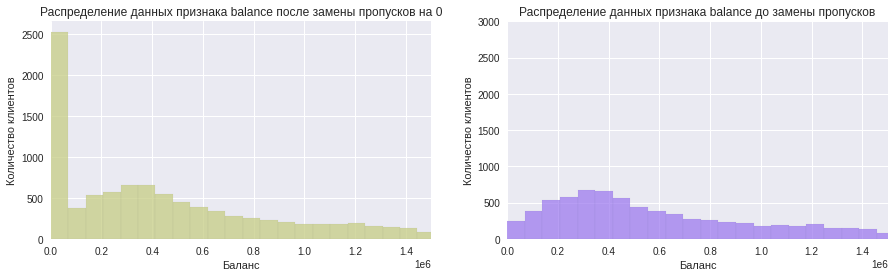

In [18]:
plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением баланса после замены пропусков на 0
ax1 = plt.subplot(1, 2, 1)
sns.histplot(bank_copy_2, x='balance', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака balance после замены пропусков на 0")
plt.xlim(0, 1500000)
plt.ylabel('Количество клиентов')
plt.xlabel('Баланс')

#строим гистограмму с распределением баланса до замены пропусков
ax2 = plt.subplot(1, 2, 2)
sns.histplot(bank, x='balance', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака balance до замены пропусков")
plt.xlim(0, 1500000)
plt.ylim(0, 3000)
plt.ylabel('Количество клиентов')
plt.xlabel('Баланс')

plt.show()

Видим ту же картину, что и с заменой медианой. Всплеск имеется в области нуля. Замена, как ожидаемо, также привела к наличию 22,95% искусственных данных в датасете, что влияет как на распределение признака, так и исказит результаты исследования.

После исследования всех пропусков мы пришли к выводу, что пропуски в столбце `age` не имеют связи ни с одним признаком, что говорит о том, что они абсолютно случайны. Такие пропуски заменять нецелесообразно. Их можно удалить, их всего 0,26%.

Пропуски по столбцу `balance` имеют зависимость от балла собственности и количества продуктов, но заполнять их медианным значением по данному срезу, или средним значением, или нулем - нецелесообразно, так как это приведет к большому количеству искусственных данных, а соответственно и к искажению результатов исследования. Так же нельзя их удалять, так как пропуски составляют 22,95% от всех данных, что тоже может нарушить результаты! Соответственно, напрашивается вывод, что пропуски лучше оставить как есть!

In [19]:
#удалим пропуски по столбцу age
bank = bank.dropna(subset=['age'])
#проверяем
display(bank.isna().sum())

user_id             0
score               0
city                0
gender              0
age                 0
equity              0
balance          2279
products            0
credit_card         0
last_activity       0
est_salary          0
churn               0
dtype: int64

Пропуски по столбцу с возрастом успешно удалены. Также наблюдаем, что пропуски в балансе тоже сократились на 16 штук. Так получилось потому, что у нас были строки с пропусками и в столбце `age` и в столбце `balance` одновременно.

### Работа с типами данных

В предыдущем шаге мы обнаружили, что тип данных в колонках `score` и `age` не соответствует ожидаемому. Заменим тип float в них на целочисленный.

In [20]:
#заменим тип данных в колонке score на целочисленный
bank['score'] = bank['score'].astype(int)
#заменим тип данных колонки age на целочисленный
bank['age'] = bank['age'].astype(int)
#проверяем
bank.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9974 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        9974 non-null   int64  
 1   score          9974 non-null   int64  
 2   city           9974 non-null   object 
 3   gender         9974 non-null   object 
 4   age            9974 non-null   int64  
 5   equity         9974 non-null   int64  
 6   balance        7695 non-null   float64
 7   products       9974 non-null   int64  
 8   credit_card    9974 non-null   int64  
 9   last_activity  9974 non-null   int64  
 10  est_salary     9974 non-null   float64
 11  churn          9974 non-null   int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 1013.0+ KB


Типы данных заменены успешно и теперь соответствуют ожидаемым.

### Проверка на наличие неявных дубликатов

Предполагая, что дубликаты все-таки могут быть в наших данных, проверим, есть ли клиенты с одинаковыми идентификаторами пользователя.

In [21]:
#проверяем дубликаты по user_id
dupl_users = bank[bank.duplicated(subset='user_id', keep=False)].sort_values(by='user_id')
#установим опцию, чтобы отобразились все строки
with pd.option_context('display.max_rows', 1000):
    display(dupl_users)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1893,116540,883,Рыбинск,Ж,55,1,"362,756.49",3,0,1,"175,920.48",1
7694,116540,887,Ярославль,Ж,38,0,NaN,1,0,1,"119,247.61",0
4866,117943,855,Рыбинск,Ж,32,6,"1,036,832.93",4,1,1,"107,792.71",1
7542,117943,880,Ярославль,Ж,40,0,NaN,1,1,0,"137,718.93",0
5863,120258,908,Рыбинск,Ж,38,4,"2,213,581.63",2,0,1,"160,327.77",1
5896,120258,905,Ярославль,М,30,0,NaN,1,1,1,"146,427.96",0
1411,123461,829,Ярославль,Ж,59,0,"96,222.44",2,0,1,"102,771.55",1
8638,123461,934,Рыбинск,М,34,0,NaN,2,1,0,"291,619.27",0
9775,124450,758,Рыбинск,Ж,36,0,"73,574.07",2,0,1,"79,963.59",0
8164,124450,859,Ярославль,Ж,38,6,"516,811.20",1,1,1,"95,144.63",1


In [22]:
#смотрим количество пользователей с дублированными ID
print(len(dupl_users))

100


Пользователи с дублированными id все-таки присутствуют в данных, их 100 штук. Такого быть не должно, так как каждому клиенту дается свой индивидуальный id на основании личных документов (паспорта, ИНН или другого). Эту информацию мы выяснили у заказчика. Скорее всего произошла какая-либо ошибка в выгрузке данных и id клиентов задублировался. Если внимательно изучить эти пары клиентов, то мы увидим различие по всем признакам, то есть тэто действительно разные клиенты. Исходя из того, что поле с идентификаторами пользователей мы использовать не будем, данные можно оставить в таблице, они могут помочь нам в исследовании.

### Проверка на наличие аномальных значений

Посмотрим наличие аномальных значений в некоторых колонках.

Ранее мы уже определили, что аномалии могут наблюдаться в колонках `balance` и `est_salary`. Проверим их.

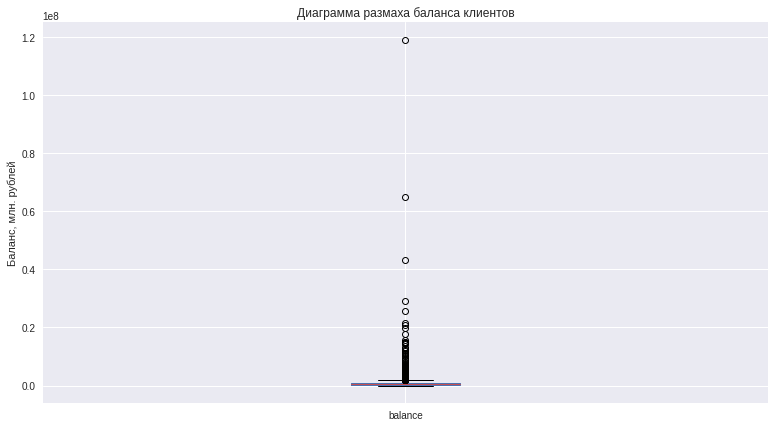

In [23]:
#смотрим выбросы в столбце balance с помощью диаграммы размаха
#plt.style.use('seaborn')
plt.figure(figsize=(13, 7))
bank.boxplot(column=['balance'])
plt.ylabel('Баланс, млн. рублей')
plt.title('Диаграмма размаха баланса клиентов')
plt.show()

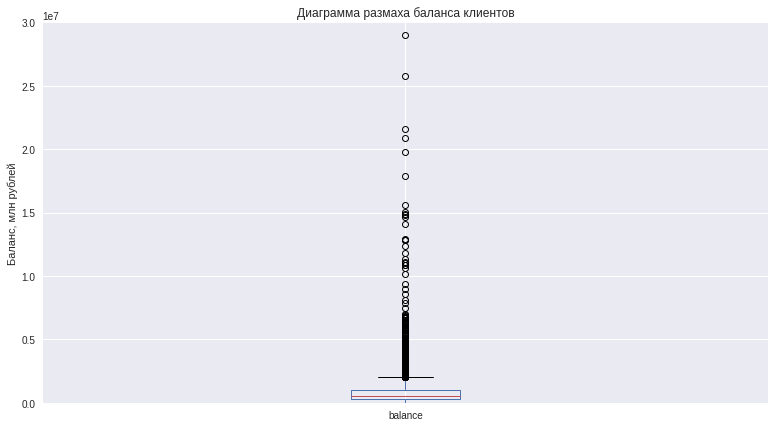

In [24]:
#смотрим поближе
#plt.style.use('seaborn')
plt.figure(figsize=(13, 7))
bank.boxplot(column=['balance'])
plt.ylabel('Баланс, млн рублей')
plt.ylim(0, 30000000)
plt.title('Диаграмма размаха баланса клиентов')
plt.show()

Диаграмма показывает, что в норме значения доходят до 2 млн денежных единиц, а все остальное считает выбросами. Но до примерно 15 млн мы все еще видим плотное скопление данных. А дальше уже единичные выбросы. Посмотрим, сколько у нас клиентов с балансом более 10 млн денежных единиц.

In [25]:
#количество клиентов с балансом более 15 млн
print(len(bank.query('balance > 10000000')))

27


Таких клиентов всего 27. Это 0,27% от всех данных. Удалять эти данные на наш взгляд нецелесообразно. Такой баланс действительно может быть у физ лиц, тем более их не много.

Перейдем к колонке `est_salary`.

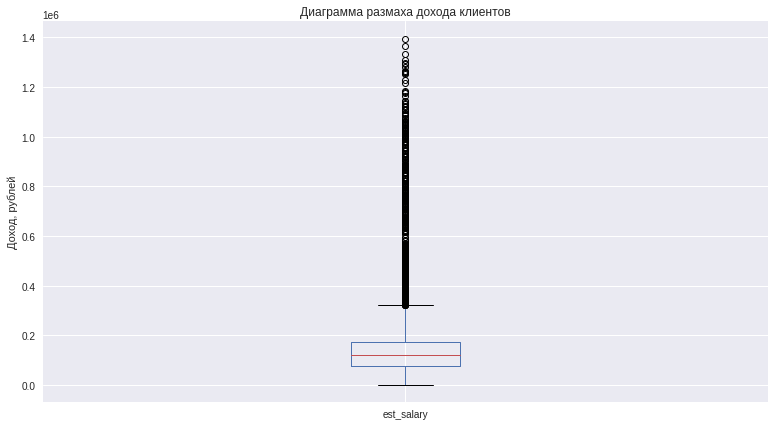

In [26]:
#смотрим выбросы в столбце balance с помощью диаграммы размаха
#plt.style.use('seaborn')
plt.figure(figsize=(13, 7))
bank.boxplot(column=['est_salary'])
plt.ylabel('Доход, рублей')
plt.title('Диаграмма размаха дохода клиентов')
plt.show()

Видим, что диаграмма показывает нормальное скопление значений дохода от 2546 до примерно 325000 рублей. Доход в 2546 рублей выглядит странно. Официально такого дохода быть не может. По официальным данным МРОТ в Ярославской области составляет 19242 рубля.

От заказчика мы узнали, что данная колонка была заполнена не на основании реальных данных от клиентов, а расчитана автоматически на основе некоторых алгоритмов.

Поскольку мы не знаем с какого по какой год у нас данные, мы не можем точно сказать, что минимальная оплата на тот момент составляла 19242 рубля. За минимальную оплату возьмем условно 15000 рублей, так как до 2021 года такая зарплата была вполне реальной как в маленьких городах, так и, например, в гос учреждениях.

Посмотрим количество клиентов с зарплатой менее 15000 рублей.

In [27]:
display(len(bank.query('est_salary < 15000')))

59

Таких клиентов всего 59, что составляет 0,59% от всех данных. Это не так много, далее можно их удалить, для более корректного представления данных.

Так же видим, что доходы клиентов плотно распределяются до отметки в 1,2 млн рублей, и единично до 1,4 млн рублей. Такие доходы вполне могут иметь место быть. Удалять такие выбросы мы не будем.

In [28]:
#удалим аномалии в доходах клиенотов до 15000 рублей
bank = bank.drop(np.where(bank['est_salary'] < 15000)[0]).reset_index(drop=True)

В первом шаге мы обнаружили, что среди клиентов есть такие, у которых 0 продуктов. Такого быть не может. Посмотрим на этих клиентов.

In [29]:
#смотрим клиентов с 0 продуктов
display(bank.query('products == 0'))

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
8888,147837,962,Рыбинск,Ж,79,3,NaN,0,0,0,"25,063.96",1


Такой клиент всего один. Удалим его. Это никак не повлияет на наши результаты.

In [30]:
#удаляем клиента с 0 продуктов
bank = bank.drop(np.where(bank['products'] == 0)[0]).reset_index(drop=True)

Проверим, как изменился наш датафрейм после удаления пропусков и аномалий.

In [31]:
print(f'Количество удаленных данных составило {(86/10000) * 100}% от исходного количества данных')

Количество удаленных данных составило 0.86% от исходного количества данных


Мы потеряли всего 0,86% от общего количества данных. Это совсем немного и на исследование это не должно повлиять.

### Категоральные значения

Мы имеем два столбца с категоральными значениями - `city` и `gender`.

Для того, чтобы нам было удобнее строить матрицу корреляций и посмотреть взаимосвязь всех признаков данные столбцы нам надо закодировать.

Начнем со столбца `gender`. Применим метод *get_dummies()*, который создаст столбцы с каждым полом и проставит бинарный код.

In [32]:
#скопируем столбец с полом в новый столбец
bank['gender_to_code'] = bank['gender']
#кодируем данные по столбцу gender
bank = pd.get_dummies(bank, prefix='', prefix_sep='', columns = ['gender_to_code'])
#проверяем
bank.head(5)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,Ж,М
0,183012,850,Рыбинск,Ж,25,1,"59,214.82",2,0,1,"75,719.14",1,1,0
1,146556,861,Рыбинск,Ж,37,5,"850,594.33",3,1,0,"86,621.77",0,1,0
2,120722,892,Рыбинск,Ж,30,0,NaN,1,1,1,"107,683.34",0,1,0
3,225363,866,Ярославль,Ж,51,5,"1,524,746.26",2,0,1,"174,423.53",1,1,0
4,157978,730,Ярославль,М,34,5,174.00,1,1,0,"67,353.16",1,0,1


Перейдем к столбцу `city`. У нас указано 3 города - Ярославль, Рыбинск, Ростов. Для кодирования применим тот же метод, что и с полом.

In [33]:
#скопируем столбец с городом в новый столбец
bank['city_to_code'] = bank['city']
#кодируем данные по столбцу city
bank = pd.get_dummies(bank, prefix='', prefix_sep='', columns = ['city_to_code'])
#проверяем
bank.head(5)

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,Ж,М,Ростов,Рыбинск,Ярославль
0,183012,850,Рыбинск,Ж,25,1,"59,214.82",2,0,1,"75,719.14",1,1,0,0,1,0
1,146556,861,Рыбинск,Ж,37,5,"850,594.33",3,1,0,"86,621.77",0,1,0,0,1,0
2,120722,892,Рыбинск,Ж,30,0,NaN,1,1,1,"107,683.34",0,1,0,0,1,0
3,225363,866,Ярославль,Ж,51,5,"1,524,746.26",2,0,1,"174,423.53",1,1,0,0,0,1
4,157978,730,Ярославль,М,34,5,174.00,1,1,0,"67,353.16",1,0,1,0,0,1


Мы успешно закодировали категориальные столбцы и подготовили данные для построения матрицы корреляций.

**Выводы по разделу:**
- Произвели замену названий столбцов на более корректные
- Удалили 26 пропусков по столбцу `age`, так как взаимосвязь их от других признаков не обнаружена, что означает, что они случайны. Пропуски по столбцу `balance` имели взаимосвязь с баллами собственности и количеством продуктов. Попытавшись заменить их на медиану и на 0 мы обнаружили сильное влияние на распределение баланса, что могло бы повлиять на результаты. Поэтому пропуски по балансу было решено оставить, во избежание их влияния на результаты.
- Заменили типы данных в столбцах `score` и `age` на подходящий целочисленный.
- Обнаружили 100 неявных дубликатов с дублирующимися id. Пришли к выводу, что это может быть связано с ошибкой в выгрузке данных. Удалять такие дубли не стали, потому что очевидно, что это разные клиенты, а id в дальнейшем анализе мы пользоваться не будем.
- Нашли аномальные значения по полю `est_salary` с низкими значениями дохода до 15000 рублей. Таких клиентов было 59. Мы их удалили без влияния на результат. Эта колонка рассчитана на основе алгоритмов, поэтому такой низкий доход мог рассчитаться ошибочно. Также на этом этапе мы обнаружили одного клиента с количеством продуктов равным 0. Такого быть не может. Это может быть ошибкой, либо этот клиент перестал пользоваться услугами банка и закрыл карту.
- Для удобства дальнейшего анализа мы закодировали категоральный столбец с полом, а так же столбец с названиями городов.
- По итогам предобработки потеряли всего лишь 0,86% от общего количества данных, благодаря чему результаты не исказятся.

## Исследовательский анализ данных

### Общее отношение отточных и оставшихся клиентов

Для начала посмотрим какой процент клиентов у банка в оттоке, а какой нет.

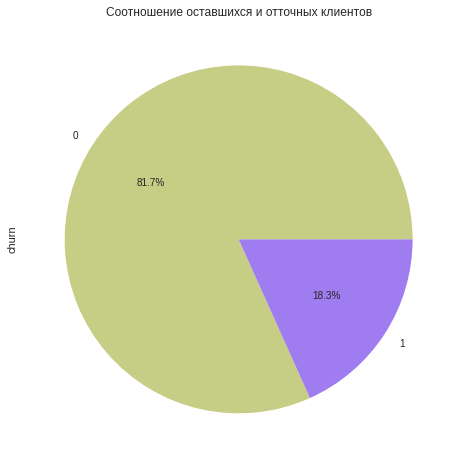

In [34]:
#строим круговую диаграмму с соотношением отточных и неотточных клиентов
#plt.style.use('seaborn')
churn_rate = bank['churn'].value_counts().plot(kind='pie', figsize=(10, 8), autopct='%1.1f%%', colors=['#C6CD85', '#9F7CEF'])
plt.title('Соотношение оставшихся и отточных клиентов')
plt.show()

Процент клиентов в оттоке составляет 18,3%, а оставшихся 81,7% от общего числа всех клиентов.

### Портрет клиента в оттоке

Посмотрим на меры центральной тенденции признаков клиентов оставшихся и попавших в отток. Посмотрим общую картину.

Расчитаем моду для пола и города, среднее и медиану для возраста, баланса, кредитного скоринга, дохода, и медиану для активности, кредитных карт, продуктов, баллов собственности.

Делаем портрет отточного клиента.

In [35]:
portrait_churn = bank.query('churn == 1').agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
portrait_churn.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
portrait_churn = portrait_churn.T
portrait_churn.columns=pd.MultiIndex.from_tuples( [('Отточные',''),("Отточные",'Среднее'),("Отточные",'Медиана')])

Делаем портрет оставшегося клиента.

In [36]:
portrait_remained = bank.query('churn == 0').agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
portrait_remained.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
portrait_remained = portrait_remained.T
portrait_remained.columns=pd.MultiIndex.from_tuples( [('Оставшиеся',''),("Оставшиеся",'Среднее'),("Оставшиеся",'Медиана')])

Объединяем.

In [37]:
gen_portrait = pd.merge(portrait_churn, portrait_remained, left_index=True, right_index=True)
gen_portrait['Отточные', 'Среднее'] = gen_portrait['Отточные', 'Среднее'].astype(float)
gen_portrait['Оставшиеся', 'Среднее'] = gen_portrait['Оставшиеся', 'Среднее'].astype(float)
gen_portrait['Относительная разница, %'] = (abs((gen_portrait['Отточные', 'Среднее'] - gen_portrait['Оставшиеся', 'Среднее']))\
                                            / gen_portrait['Оставшиеся', 'Среднее']) * 100
gen_portrait = gen_portrait.fillna('')
gen_portrait

Отточные                         Оставшиеся             \
                                   Среднее    Медиана               Среднее   
Пол                         М                                  Ж              
Город               Ярославль                          Ярославль              
Возраст                              41.42      39.00                 43.00   
Баланс                        1,135,552.18 783,908.90            734,302.22   
Кредитный скоринг                   863.50     866.50                845.48   
Доход                           148,358.01 125,408.88            147,886.05   
Активность                                       1.00                         
Кредитная карта                                  1.00                         
Продукты                                         2.00                         
Балл собственности                               4.00                         

                              Относительная разница, %  
                      Медиана                           
Пол                                                     
Город                                                   
Возраст                 40.00                     3.69  
Баланс             475,609.85                    54.64  
Кредитный скоринг      848.00                     2.13  
Доход              118,279.00                     0.32  
Активность               0.00                           
Кредитная карта          1.00                           
Продукты                 2.00                           
Балл собственности       3.00

Теперь можем составить **портрет типичного отточного клиента**:
- мужчина
- в основном из Ярославля
- со средним возрастом в 41,42 года
- активный
- со средним доходом в 148358 рублей
- средний баланс на счету 1135552 рубля
- имеет кредитную карту
- пользуется 2 продуктами
- медианный балл собственности 4
- средний балл кредитного скоринга 863,5

Также видим, что у отточных клентов в среднем балл кредитного скоринга выше на 2,13%, средний баланс выше на 54,64%, средний возраст ниже на 3,69%, средний доход выше на 0,32%. 

Видим что все показатели, где мы считали среднее значение сместились в меньшую сторону по медиане, за исключением кредитного скоринга.

### Распределение признаков в разбивке по оттоку

Первым посмотрим распределение баллов крединого скоринга.

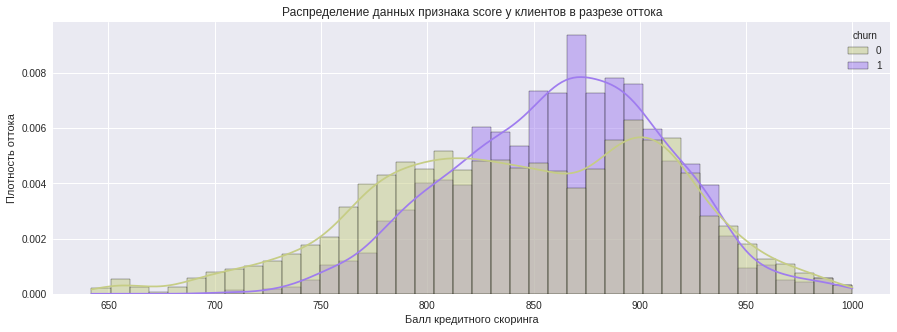

In [38]:
plt.figure(figsize=(15, 5))
sns.histplot(data=bank, x='score', hue='churn', kde=True, stat="density", common_norm=False, palette=['#C6CD85', '#9F7CEF'])
plt.title(f"Распределение данных признака score у клиентов в разрезе оттока")
plt.xlabel('Балл кредитного скоринга')
plt.ylabel('Плотность оттока')
plt.show()

На графике видим, что отток превышает в диапазоне баллов кредитного скоринга от 820 до 910. Слабое влияние этого признака на отток вероятно.

Далее посмотрим распределение по городам.

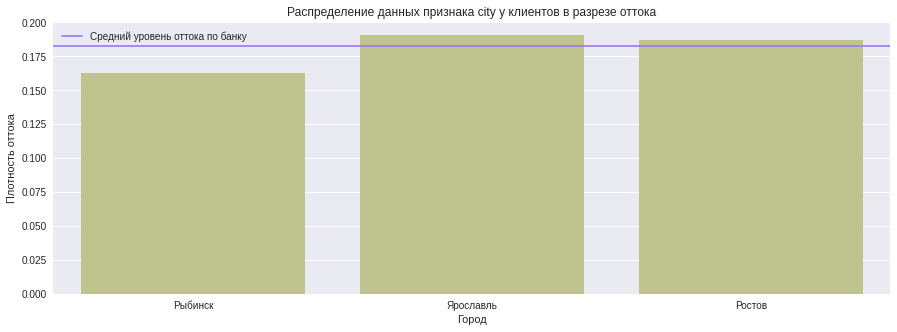

In [39]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='city', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака city у клиентов в разрезе оттока")
plt.xlabel('Город')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Что касаемо городов, видим, что данные по Рыбинску лежат ниже среднего значения оттока по банку, в то время как данные по Ярославлю и Ростову немного превышают этот показатель. Речь о слабом влиянии города на отток.

Посмотрим на распределение признака пола по оттоку.

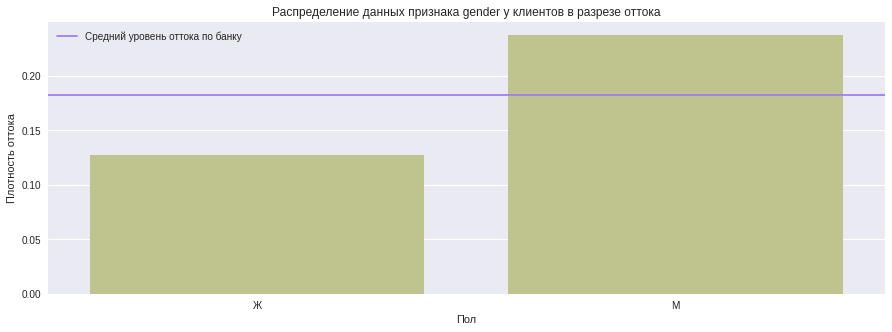

In [40]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='gender', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака gender у клиентов в разрезе оттока")
plt.xlabel('Пол')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Данные по женщинам лежат ниже среднего значения оттока по банку, в то время как данные по мужчинам, наоборот, лежат выше. Влияние пола на отток прослеживается, причем чаще отваливаются мужчины.

Переходим к возрасту.

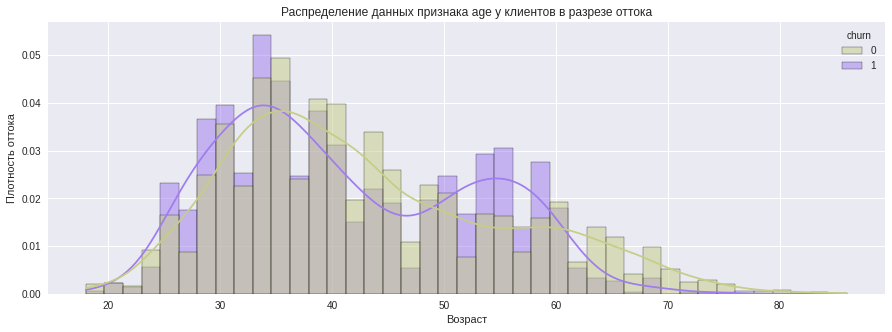

In [41]:
plt.figure(figsize=(15, 5))
sns.histplot(data=bank, x='age', hue='churn', kde=True, stat="density", common_norm=False, palette=['#C6CD85', '#9F7CEF'])
plt.title(f"Распределение данных признака age у клиентов в разрезе оттока")
plt.xlabel('Возраст')
plt.ylabel('Плотность оттока')
plt.show()

Данные по возрасту клиентов в оттоке в некоторых диапазонах находятся выше лояльных клиентов. Такие превышения мы видим в области 21 года, 25-35 лет, 50-60 лет. Видимо, кдиенты такого возраста попадают в отток чаще. Некоторое влияние возраста на отток может присутствовать.

Переходим к баллам собственности.

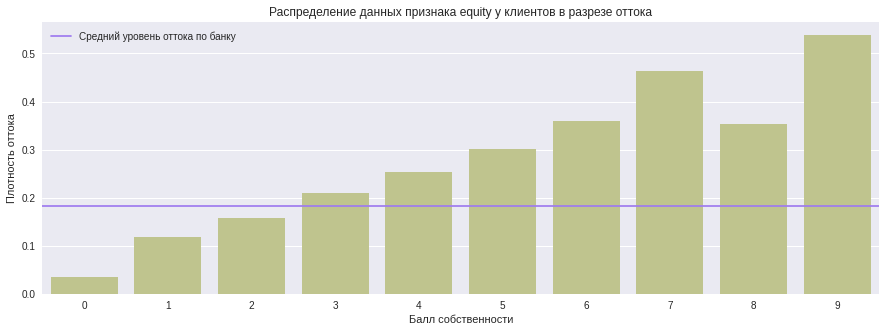

In [42]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='equity', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака equity у клиентов в разрезе оттока")
plt.xlabel('Балл собственности')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Данные по баллам собственности в диапазоне от 3 до 9 лежат выше среднего оттока по банку, что говорит о влиянии данного признака на отток. Можно было бы даже сказать, что, чем выше балл собственности, тем больше клиент склонен к оттоку, но в области 8 видим небольшой упадок.

Теперь перейдем к балансу.

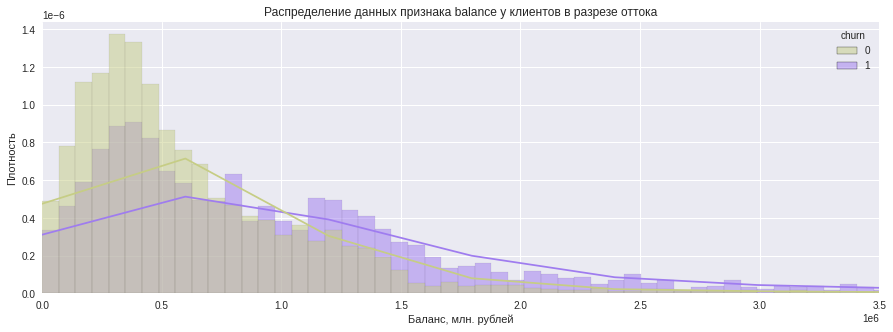

In [43]:
plt.figure(figsize=(15, 5))
sns.histplot(data=bank, x='balance', hue='churn', kde=True, stat="density", common_norm=False, palette=['#C6CD85', '#9F7CEF'])
plt.title(f"Распределение данных признака balance у клиентов в разрезе оттока")
plt.xlabel('Баланс, млн. рублей')
plt.ylabel('Плотность')
plt.xlim(0, 3500000)
plt.show()

На графике распределения баланса видим, что примерно с 1,2 млн рублей отток начинает превышать лояльность. Исходя из этого можно предположить, что при большем балансе на счету, клиенты менее склонны к оттоку. Некая зависимость оттока от баланса скорее всего присутствует.

Перейдем к количеству продуктов.

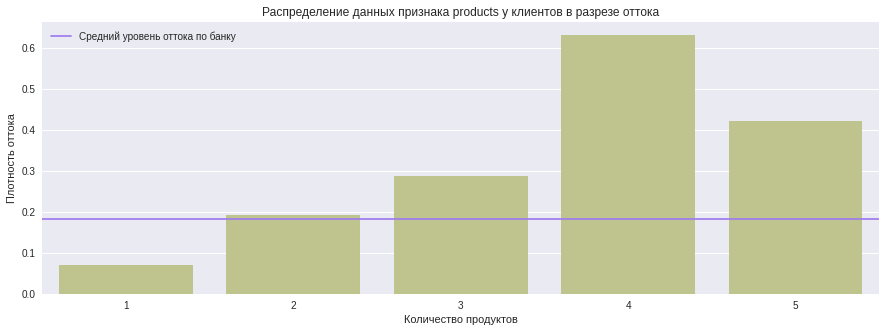

In [44]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='products', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака products у клиентов в разрезе оттока")
plt.xlabel('Количество продуктов')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Все данные по количеству продуктов лежат выше среднего оттока по банку, за исключением 1 продукта. Больше всего к оттоку склонны клиенты с 4 продуктами. Влияние количества продуктов на отток явно прослеживается.

Что же можно сказать о наличии кредитной карты?

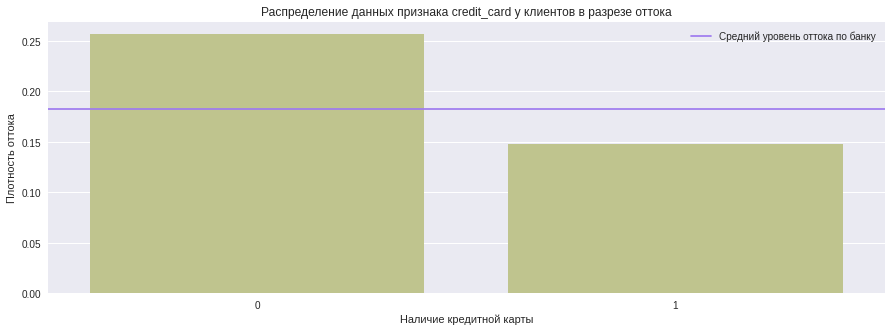

In [45]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='credit_card', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака credit_card у клиентов в разрезе оттока")
plt.xlabel('Наличие кредитной карты')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Данные с клиентами без кредитной карты лежат выше среднего значения оттока по банку, в то время как данные с клиентами, имеющими кредитку, лежат ниже. Это указывает на влияние отсутствия кредитной карты на отток. Клиенты без кредитной карты попадают в отток чаще. 

Перейдем к активности.

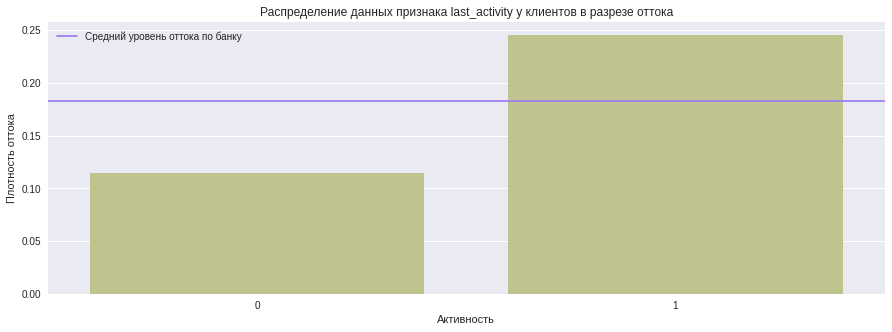

In [46]:
plt.figure(figsize=(15, 5))
sns.barplot(data=bank, x='last_activity', y='churn', color='#C6CD85', ci=None)
plt.title(f"Распределение данных признака last_activity у клиентов в разрезе оттока")
plt.xlabel('Активность')
plt.ylabel('Плотность оттока')
plt.axhline(bank['churn'].mean(), color='#9F7CEF')
plt.legend(labels=['Средний уровень оттока по банку'])
plt.show()

Активные клиенты находятся выше среднего значения оттока по банку, а неактивные наоборот. Получается интересная и парадоксальная картина - чаще в отток попадают активные клиенты. Данный показатель имеет влияние на отток.

Посмотрим на распределение доходов.

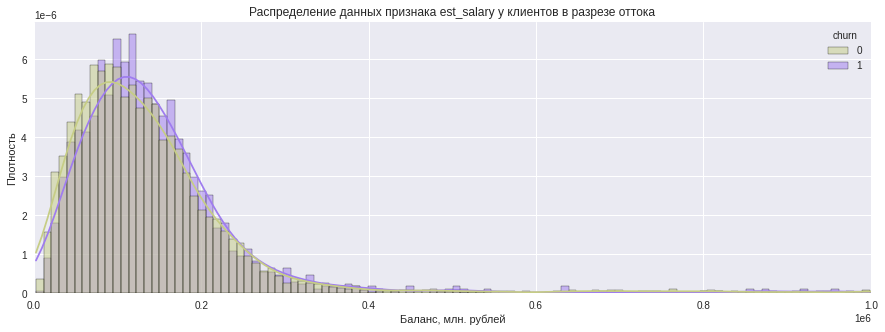

In [47]:
plt.figure(figsize=(15, 5))
sns.histplot(data=bank, x='est_salary', hue='churn', kde=True, stat="density", common_norm=False, palette=['#C6CD85', '#9F7CEF'])
plt.title(f"Распределение данных признака est_salary у клиентов в разрезе оттока")
plt.xlabel('Баланс, млн. рублей')
plt.ylabel('Плотность')
plt.xlim(0, 1000000)
plt.show()

Распределения по доходам выглядят похоже. Превышение оттока в доходах прослеживается в области от примерно 100 тыс. до 200 тыс. рублей, далее превышение идет с чередованием. Нельзя четко говорить о влиянии дохода на отток, если только о слабом.

### Матрица корреляций

Для того, чтобы определить правильность предположений, сделанных в предыдущем шаге, построим матрицу корреляций и псмотрим на взаимосвязь признаков и оттока.

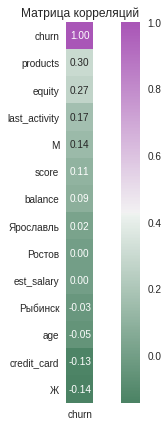

In [48]:
#расчитаем корреляцию
cm = bank.drop(columns='user_id').corr()

#строим матрицу
plt.figure(figsize=(10, 7))
sns.heatmap(cm[['churn']].sort_values(by='churn', ascending=False), annot=True, square=True, fmt='.2f', cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True))
plt.title('Матрица корреляций')
plt.show()

На матрице не видим явной зависимости оттока от признаков. 

Если отталкиваться от шкалы тесноты связи по Чеддоку, то прослеживается умеренная зависимость оттока от количества продуктов с коэффициентом корреляции 0,3, слабая взаимосвязь от баллов собственности, активности, пола(конкретно мужского) и кредитного скроринга с коэффициентами корреляции 0,27, 0,17, 0,14 и 0,11 соответственно. Также есть слабая обратная взаимосвязь по женскому полу и наличию кредитной карты с коэффициентами корреляции -0,14 и -0,13 соответственно.

Остальные признаки, как города, баланс, доход и возраст имеют коэффициенты корреляции почти или равные 0. Это говорит об отсутствии взаимосвязи оттока от этих признаков. 

**Выводы по разделу:**
Процент клиентов в оттоке составляет 18,3%, а оставшихся 81,7% от общего числа всех клиентов.

Составили общий **портрет отточного клиента**:
- мужчина
- в основном из Ярославля
- со средним возрастом в 41,42 года
- активный
- со средним доходом в 148358 рублей
- средний баланс на счету 1135552 рубля
- имеет кредитную карту
- пользуется 2 продуктами
- медианный балл собственности 4
- средний балл кредитного скоринга 863,5

У отточных клентов в среднем балл кредитного скоринга выше на 2,09%, средний баланс выше на 35,34%, средний возраст ниже на 3,84%, средний доход выше на 0,32%. 

Построив распределения признаков, мы увидели следующие закономерности:
- Отток превышает лояльность в диапазоне баллов кредитного скоринга от 820 до 910. Слабое влияние этого признака на отток вероятно.
- Данные по Рыбинску лежат ниже среднего значения оттока по банку, в то время как данные по Ярославлю и Ростову немного превышают этот показатель. Тут речь идет об очень слабом влиянии города на отток.
- Данные по женщинам лежат ниже среднего значения оттока по банку, в то время как данные по мужчинам, наоборот, лежат выше. Влияние пола на отток прослеживается, причем чаще отваливаются мужчины.
- Данные по возрасту клиентов в оттоке в некоторых диапазонах находятся выше лояльных клиентов. Такие превышения мы видим в области 21 года, 25-35 лет, 50-60 лет. Видимо, кдиенты такого возраста попадают в отток чаще. Некоторое влияние возраста на отток может присутствовать.
- Данные по баллам собственности в диапазоне от 3 до 9 лежат выше среднего оттока по банку, что говорит о влиянии данного признака на отток.
- Примерно с 1,2 млн рублей на балансе у клиентов отток начинает превышать лояльность. Исходя из этого можно предположить, что при большем балансе на счету, клиенты менее склонны к оттоку. Некая зависимость оттока от баланса скорее всего может присутствовать.
- Все данные по количеству продуктов лежат выше среднего оттока по банку, за исключением 1 продукта. Больше всего к оттоку склонны клиенты с 4 продуктами. Влияние количества продуктов на отток явно прослеживается.
- Данные с клиентами без кредитной карты лежат выше среднего значения оттока по банку, в то время как данные с клиентами, имеющими кредитку, лежат ниже. Это указывает на некое влияние отсутствия кредитной карты на отток. Клиенты без кредитной карты попадают в отток чаще.
- Активные клиенты находятся выше среднего значения оттока по банку, а неактивные наоборот. Чаще в отток попадают активные клиенты. Данный показатель имеет влияние на отток.
- Превышение оттока в доходах прослеживается в области от примерно 100 тыс. до 200 тыс. рублей, далее превышение идет с чередованием. Нельзя четко говорить о влиянии дохода на отток, если только о слабом.

На основе матрицы корреляций проследили слабую зависимость оттока от баллов собственности, количества продуктов, наличия кредитной карты, активности и пола.

Опираясь на оба эти исследования, выделим **пол, баллы собственности, активность клиентов, количество продуктов и наличие кредитной карты** как признаки с наибольшим влиянием на отток в банке.

## Гипотезы

Чтобы подтвердить наши выводы из предыдущего шага, выдвинем несколько гипотез и проверим их.

Для начала выделим наши выборки и посчитаем их размер.

In [49]:
#зададим переменные с отточными и оставшимися клиентами
churn_users = bank.query('churn == 1') #клиенты в оттоке
remained_users = bank.query('churn == 0') #оставшиеся клиенты
#посмотрим размеры выборок
print(f'Размер выборки клиентов в оттоке: {len(churn_users)}')
print(f'Размер выборки оставшихся клиентов: {len(remained_users)}')

Размер выборки клиентов в оттоке: 1812
Размер выборки оставшихся клиентов: 8102


Рзмер выборок достаточно отличается. Это нужно будет учесть при проведении теста.

### Гипотеза о доходах клиентов

В первую очередь проверим гипотезу, предложенную нам заказчиком, о разнице в доходе оставшихся и отточных клиентов.

**Нулевая гипотеза (Н0):** Средний доход оставшихся клиентов и клиентов в оттоке равен.

**Альтернативная гипотеза (Н1):** Средний доход оставшихся клиентов и клиентов в оттоке различается.

Для выбора теста для проверки теста сначала проверим данные на соответствие некоторым условиям:
- Выборки должны быть независимые (наши выборки не зависят друг от друга);
- Выборочные средние имеют нормальное распределение;
- Дисперсии рассматриваемых выборок равны.

Для проверки выборок на нормальность используем тест Шапиро-Уилка.

In [50]:
#задаем уровень статистической значимости
alpha = 0.05

#применяем тест Шапиро-Уилка к выборке клиентов в оттоке
shapiro_test_stat, pvalue_1 = st.shapiro(churn_users.est_salary)
#применяем тест Шапиро-Уилка к выборке оставшихся клиентов
shapiro_test_stat, pvalue_0 = st.shapiro(remained_users.est_salary)

#вывод о нормальности распределения клиентов в оттоке
print('p-значение выборки клиентов в оттоке: ', pvalue_1)
if pvalue_1 < alpha:
    print('Распределение дохода клиентов в оттоке ненормальное')
else:
    print('Распределение дохода клиентов в оттоке нормальное')
    
#вывод о нормальности распределения оставшихся клиентов
print('p-значение выборки оставшихся клиентов: ', pvalue_0)
if pvalue_0 < alpha:
    print('Распределение дохода оставшихся клиентов ненормальное')
else:
    print('Распределение дохода оставшихся клиентов нормальное')

p-значение выборки клиентов в оттоке:  0.0
Распределение дохода клиентов в оттоке ненормальное
p-значение выборки оставшихся клиентов:  0.0
Распределение дохода оставшихся клиентов ненормальное


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Построим график распределения доходов.

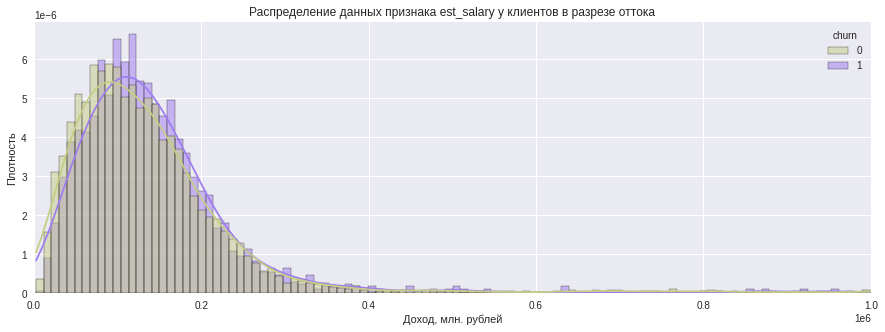

In [51]:
plt.figure(figsize=(15, 5))
sns.histplot(data=bank, x='est_salary', hue='churn', stat="density", common_norm=False, kde=True, palette=['#C6CD85', '#9F7CEF'])
plt.title(f"Распределение данных признака est_salary у клиентов в разрезе оттока")
plt.xlabel('Доход, млн. рублей')
plt.ylabel('Плотность')
plt.xlim(0, 1000000)
plt.show()

Распределение действительно не выглядит, как нормальное. Но в реальности нормальное распределение встретить невозможно.

Посчитаем дисперсии двух выборок и сравним их.

In [52]:
#считаем дисперсии
print('Дисперсия по доходу клиентов в оттоке:', churn_users.est_salary.var())
print('Дисперсия по доходу оставшихся клиентов:', remained_users.est_salary.var())

Дисперсия по доходу клиентов в оттоке: 15136702561.618155
Дисперсия по доходу оставшихся клиентов: 20442472302.68749


Дисперсии двух выборок не равны.

На этапе предобработки, мы уже проверяли данные на выбросы и решили их оставить. Выбросы в данных есть. Проверим еще раз в разрезе выборок.

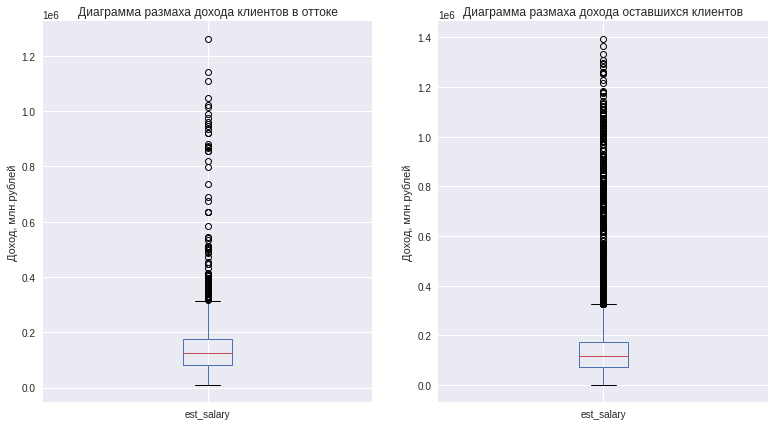

In [53]:
#смотрим выбросы по доходу клиентов в двух выборках
plt.figure(figsize=(13, 7))

ax1 = plt.subplot(1, 2, 1)
churn_users.boxplot(column=['est_salary'], ax=ax1)
plt.ylabel('Доход, млн.рублей')
plt.title('Диаграмма размаха дохода клиентов в оттоке')

ax2 = plt.subplot(1, 2, 2)
remained_users.boxplot(column=['est_salary'], ax=ax2)
plt.ylabel('Доход, млн.рублей')
plt.title('Диаграмма размаха дохода оставшихся клиентов')

plt.show()

Выбросы есть!

Исходя из проведенных расчетов, для проверки этой гипотезы лучше было бы применить критерий Манна-Уитни, так как он используется для сравнения различий между двумя выборками, когда распределение выборки не является нормальным, а также устойчив к выбросам.

Так как у нас присутствует 2 независимые выборки, с ненормальным распределением, различием в дисперсиях и выбросами применим для проверки гипотезы критерий Манна-Уитни.

In [54]:
#выведем средний доход клиентов оставшихся и в оттоке
print(f'Средний доход клиентов в оттоке: {round(np.mean(churn_users.est_salary), 2)}')
print(f'Средний доход оставшихся клиентов: {round(np.mean(remained_users.est_salary), 2)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

#применяем критерий Манна-Уитни
results = st.mannwhitneyu(churn_users.est_salary, remained_users.est_salary)

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средний доход клиентов в оттоке: 148358.01
Средний доход оставшихся клиентов: 147886.05
р-значение: 0.00023677609858635055
Отвергаем нулевую гипотезу


Гипотезу о том, что средний доход клиентов в оттоке и оставшихся клиентов равен, пришлось отвергнуть в пользу альтернативной. Несмотря на то, что  разница в рассчитанных нами средних доходах совсем небольшая (472 рубля), скорее всего она статистически значима.

### Гипотеза о баллах собственности

В исследовательском анализе мы увидели некую взаимосвязь оттока от баллов собственности. Поэтому сформулируем гипотезу.

**Нулевая гипотеза (Н0):** Средний балл собственности оставшихся клиентов и клиентов в оттоке равен.

**Альтернативная гипотеза (Н1):** Средний балл собственности оставшихся клиентов и клиентов в оттоке различается.

Перед проверкой гипотезы проверим данные на нормальность.

In [55]:
#задаем уровень статистической значимости
alpha = 0.05

#применяем тест Шапиро-Уилка к выборке клиентов в оттоке
shapiro_test_stat, pvalue_1 = st.shapiro(churn_users.equity)
#применяем тест Шапиро-Уилка к выборке оставшихся клиентов
shapiro_test_stat, pvalue_0 = st.shapiro(remained_users.equity)

#вывод о нормальности распределения клиентов в оттоке
print('p-значение выборки клиентов в оттоке: ', pvalue_1)
if pvalue_1 < alpha:
    print('Распределение баллов собственности клиентов в оттоке ненормальное')
else:
    print('Распределение баллов собственности клиентов в оттоке нормальное')
    
#вывод о нормальности распределения оставшихся клиентов
print('p-значение выборки оставшихся клиентов: ', pvalue_0)
if pvalue_0 < alpha:
    print('Распределение баллов собственности оставшихся клиентов ненормальное')
else:
    print('Распределение баллов собственности оставшихся клиентов нормальное')

p-значение выборки клиентов в оттоке:  5.496986990320895e-30
Распределение баллов собственности клиентов в оттоке ненормальное
p-значение выборки оставшихся клиентов:  0.0
Распределение баллов собственности оставшихся клиентов ненормальное


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Построим график распределения баллов собственности.

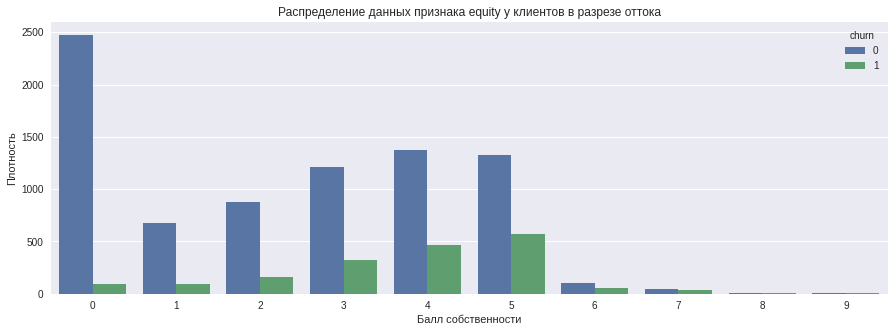

In [56]:
plt.figure(figsize=(15, 5))
sns.countplot(data=bank, x='equity', hue='churn')
plt.title(f"Распределение данных признака equity у клиентов в разрезе оттока")
plt.xlabel('Балл собственности')
plt.ylabel('Плотность')
plt.show()

Распределение также явно не выглядит нормальным.

Расчитаем дисперсии по выборкам.

In [57]:
#считаем дисперсии
print('Дисперсия по баллам собственности клиентов в оттоке:', churn_users.equity.var())
print('Дисперсия по баллам собственности оставшихся клиентов:', remained_users.equity.var())

Дисперсия по баллам собственности клиентов в оттоке: 2.512563948789773
Дисперсия по баллам собственности оставшихся клиентов: 3.886534147952087


Разница в дисперсиях присутствует.

У нас присутствует 2 независимые выборки, с ненормальным распределением, с различием в дисперсиях и без выбросов.

Обратимся к ЦПТ, которая галсит, что сумма независимых одинаково распределённых случайных величин стремится к нормальному распределению по мере увеличения их количества. Что означает, что, если в выборке достаточно наблюдений, выборочное среднее распределено близко к нормальному.

Мы имеем выборки с достаточным количеством наблюдений, а соответственно выборочное среднее будет распределено близко к нормальному, если следовать ЦПТ. Поэтому можем применить t-тест с учетом ЦПТ.

Так как у нас присутствует две независимые выборки, для проверки гипотезы используем метод `scipy.stats.ttest_ind()`. В связи с тем, что у нас выборки разного размера и их дисперсии различаются применим также параметр *equal_var=False*.

In [58]:
#выведем средний балл собственности клиентов оставшихся и в оттоке
print(f'Средний балл собственности клиентов в оттоке: {round(np.mean(churn_users.equity), 2)}')
print(f'Средний балл собственности оставшихся клиентов: {round(np.mean(remained_users.equity), 2)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

#так как размер выборок достаточно отличается, сделаем параметр equal_var равным False
results = st.ttest_ind(churn_users.equity, 
                       remained_users.equity,
                       equal_var=False)

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средний балл собственности клиентов в оттоке: 3.77
Средний балл собственности оставшихся клиентов: 2.38
р-значение: 6.624740056168002e-197
Отвергаем нулевую гипотезу


Гипотеза о равенстве среднего балла собственности для двух групп клиентов была отвергнута в пользу альтернативной.

Средний балл собственности клиентов в оттоке составил 3,77, а оставшихся - 2,38. Разница в 1,39. Это действительно существенно для данного признака. Данная гипотеза неким образом подтверждает наш вывод о том, что балл собственности имеет влияние на отток клиентов. Причем в отток попадают клиенты с бОльшим баллом собственности.

### Гипотеза о количестве продуктов

Так же мы заметили несильное влияние количества продуктов у клиента на отток. Сформулируем гипотезу.

**Нулевая гипотеза (Н0):** Среднее количество продуктов оставшихся клиентов и клиентов в оттоке равно.

**Альтернативная гипотеза (Н1):** Среднее количество продуктов оставшихся клиентов и клиентов в оттоке различается.

Для начала проверим данные на нормальность.

In [59]:
#задаем уровень статистической значимости
alpha = 0.05

#применяем тест Шапиро-Уилка к выборке клиентов в оттоке
shapiro_test_stat, pvalue_1 = st.shapiro(churn_users.products)
#применяем тест Шапиро-Уилка к выборке оставшихся клиентов
shapiro_test_stat, pvalue_0 = st.shapiro(remained_users.products)

#вывод о нормальности распределения клиентов в оттоке
print('p-значение выборки клиентов в оттоке: ', pvalue_1)
if pvalue_1 < alpha:
    print('Распределение количества продуктов клиентов в оттоке ненормальное')
else:
    print('Распределение количества продуктов клиентов в оттоке нормальное')
    
#вывод о нормальности распределения оставшихся клиентов
print('p-значение выборки оставшихся клиентов: ', pvalue_0)
if pvalue_0 < alpha:
    print('Распределение количества продуктов оставшихся клиентов ненормальное')
else:
    print('Распределение количества продуктов оставшихся клиентов нормальное')

p-значение выборки клиентов в оттоке:  2.7166132548786634e-40
Распределение количества продуктов клиентов в оттоке ненормальное
p-значение выборки оставшихся клиентов:  0.0
Распределение количества продуктов оставшихся клиентов ненормальное


/opt/conda/lib/python3.9/site-packages/scipy/stats/_morestats.py:1800: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


Построим распределение.

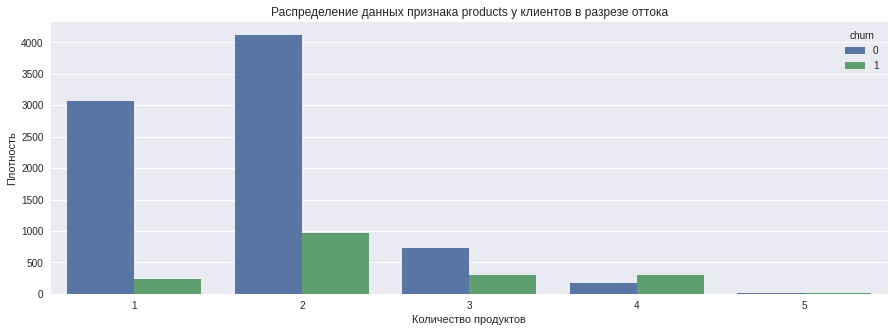

In [60]:
plt.figure(figsize=(15, 5))
sns.countplot(data=bank, x='products', hue='churn')
plt.title(f"Распределение данных признака products у клиентов в разрезе оттока")
plt.xlabel('Количество продуктов')
plt.ylabel('Плотность')
plt.show()

Распределение явно ненормальное.

Посчитаем дисперсии.

In [61]:
#считаем дисперсии
print('Дисперсия по количеству продуктов клиентов в оттоке:', churn_users.products.var())
print('Дисперсия по количеству продуктов оставшихся клиентов:', remained_users.products.var())

Дисперсия по количеству продуктов клиентов в оттоке: 0.8510817508407659
Дисперсия по количеству продуктов оставшихся клиентов: 0.5090369362044865


Дисперсии отличаются.

У нас есть 2 независимые друг от друга выборки, с ненормальным распределением, отличающимися дисперсиями и без выбросов. 
Ситуация похожа на ситуацию с предыдущей гипотезой. Применим критерий для проверки по аналогии.

Мы имеем выборки с достаточным количеством наблюдений, а соответственно выборочное среднее будет распределено близко к нормальному, если следовать ЦПТ. Поэтому можем применить t-тест с учетом ЦПТ.

Так как у нас присутствует две независимые выборки, для проверки гипотезы используем метод `scipy.stats.ttest_ind()`. В связи с тем, что у нас выборки разного размера и их дисперсии различаются применим также параметр *equal_var=False*.

In [62]:
#выведем среднее количество продуктов клиентов оставшихся и в оттоке
print(f'Среднее количество продуктов клиентов в оттоке: {round(np.mean(churn_users.products), 2)}')
print(f'Среднее количество продуктов оставшихся клиентов: {round(np.mean(remained_users.products), 2)}')

#выбираем уровень статистической значимости
#если p-value окажется меньше него, отвергнем гипотезу
alpha = 0.05

#так как размер выборок достаточно отличается, сделаем параметр equal_var равным False
results = st.ttest_ind(churn_users.products, 
                       remained_users.products,
                       equal_var=False)

#выведем полученное p-value
print('р-значение:', results.pvalue)

#вывод об отвержении или неотвержении нулевой гипотезы
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Среднее количество продуктов клиентов в оттоке: 2.38
Среднее количество продуктов оставшихся клиентов: 1.76
р-значение: 1.2748175204904441e-137
Отвергаем нулевую гипотезу


Нулевая гипотеза отвергнута в пользу альтернативной.  

Среднее количество продуктов у клиентов в оттоке составляет 2,38, а оставшихся - 1,76. Это является подтверждением нашим предположениям о влиянии данного признака на отток. В оттоке клиенты с бОльшим средним количеством продуктов на 0,62.

### Гипотеза о кредитных картах

Проверим предположение, что наличие или остутствие кредитной карты влияет на отток. Сформулируем гипотезу.

**Нулевая гипотеза (Н0):** Среди оставшихся клиентов и клиентов в оттоке нет разницы в наличии кредитных карт.

**Альтернативная гипотеза (Н1):** Среди оставшихся клиентов и клиентов в оттоке есть различие в наличии кредитных карт.

В связи с тем, что признак наличия/отсутствия кредитной карты является бинарным, проверить гипотезу нам поможет Z-test для пропорций. Воспользуемся им.

In [63]:
#выведем среднее количество кредитных карт у клиентов оставшихся и в оттоке
print(f'Среднее количество кредитных карт у клиентов в оттоке: {round(np.mean(churn_users.credit_card), 2)}')
print(f'Среднее количество кредитных карт у оставшихся клиентов: {round(np.mean(remained_users.credit_card), 2)}')

alpha = 0.05

#пропорция выборки с клиентами в оттоке
p1 = len(churn_users.query('credit_card == 1')) / len(churn_users)
#пропорция выборки с оставшимися клиентами
p2 = len(remained_users.query('credit_card == 1')) / len(remained_users)
#общая объединенная доля выборки
p = (len(churn_users.query('credit_card == 1')) + len(remained_users.query('credit_card == 1'))) / (len(churn_users) + len(remained_users))
#разница пропорций
diff = p1 - p2
#рассчитываем тестовую статистику z
z_value = diff / mth.sqrt(p * (1 - p) * (1 / len(churn_users) + 1 / len(remained_users)))
# задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
distr = st.norm(0, 1) 
#расчитываем р-значение
p_value = (1 - distr.cdf(abs(z_value))) * 2


#выведем полученное p-value
print('р-значение:', p_value)

#вывод об отвержении или неотвержении нулевой гипотезы
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Среднее количество кредитных карт у клиентов в оттоке: 0.55
Среднее количество кредитных карт у оставшихся клиентов: 0.71
р-значение: 0.0
Отвергаем нулевую гипотезу


Нулевая гипотеза о том, что у оставшихся и отточных клиентов нет различия в наличии кредитных карт, была отвергнута в пользу альтернативной. Различия все же присутствуют.

Среди клиентов в оттоке кредитные карты есть у 55% клиентов, а среди оставшихся - у 71% клиентов. Наличие кредитной карты побуждает клиента оставаться в банке. Соотношение клиентов с наличием и без кредитных карт среди клиентов в оттоке примерно одинаковое. Есть некое влияние отсутствия креитной карты на попадание в отток, что мы и предполагали ранее.

### Гипотеза об активности клиентов

Для проверки влияние активности клиентов на отток, сформулируем гипотезу.

**Нулевая гипотеза (Н0):** Среди оставшихся клиентов и клиентов в оттоке нет разницы в активности.

**Альтернативная гипотеза (Н1):** Среди оставшихся клиентов и клиентов в оттоке есть различие в активности.

В связи с тем, что признак активности является бинарным, проверить гипотезу нам поможет Z-test для пропорций. Воспользуемся им.

In [64]:
#выведем среднее количество актиных клиентов среди оставшихся и в оттоке
print(f'Среднее число активных клиентов в оттоке: {round(np.mean(churn_users.last_activity), 2)}')
print(f'Среднее число активных среди оставшихся клиентов: {round(np.mean(remained_users.last_activity), 2)}')

alpha = 0.05

#пропорция выборки с клиентами в оттоке
p1 = len(churn_users.query('last_activity == 1')) / len(churn_users)
#пропорция выборки с оставшимися клиентами
p2 = len(remained_users.query('last_activity == 1')) / len(remained_users)
#общая объединенная доля выборки
p = (len(churn_users.query('last_activity == 1')) + len(remained_users.query('last_activity == 1'))) / (len(churn_users) + len(remained_users))
#разница пропорций
diff = p1 - p2
#рассчитываем тестовую статистику z
z_value = diff / mth.sqrt(p * (1 - p) * (1 / len(churn_users) + 1 / len(remained_users)))
# задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
distr = st.norm(0, 1) 
#расчитываем р-значение
p_value = (1 - distr.cdf(abs(z_value))) * 2


#выведем полученное p-value
print('р-значение:', p_value)

#вывод об отвержении или неотвержении нулевой гипотезы
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Среднее число активных клиентов в оттоке: 0.7
Среднее число активных среди оставшихся клиентов: 0.48
р-значение: 0.0
Отвергаем нулевую гипотезу


Нулевая гипотеза о том, что нет разницы в активности между отточными и оставшимися клиентами, не поддтвердилась. В таком случае мы принимаем альтернативную гипотезу о различии в активности клиентов двух групп.

В среднем около 70% клиентов среди отточных активны, в то время как среди оставшихся активны 48%. Таким образом, подтверждаем наше предположение, что есть влияние активности клиента на попадание его в отток.

### Гипотеза о влиянии пола

Ранее нами было подмечено, что чаще в отток попадают мужчины, а среди оставшихся женщин чуть больше. Сформулируем гипотезу и сделаем вывод о влиянии пола на отток.

**Нулевая гипотеза (Н0):** Соотношение мужчин среди оставшихся клиентов и клиентов в оттоке одинаковое.

**Альтернативная гипотеза (Н1):** Соотношение мужчин среди оставшихся клиентов и клиентов в оттоке имеет различие.

В связи с тем, что признак пола является бинарным, проверить гипотезу нам поможет Z-test для пропорций. Воспользуемся им.

In [65]:
#выведем соотношение мужчин клиентов среди оставшихся и в оттоке
print(f'Сотношение мужчин клиентов в оттоке: {round(np.mean(churn_users.М), 2)}')
print(f'Соотношение мужчин оставшихся клиентов: {round(np.mean(remained_users.М), 2)}')


alpha = 0.05

#пропорция выборки с клиентами в оттоке
p1 = len(churn_users.query('М == 1')) / len(churn_users)
#пропорция выборки с оставшимися клиентами
p2 = len(remained_users.query('М == 1')) / len(remained_users)
#общая объединенная доля выборки
p = (len(churn_users.query('М == 1')) + len(remained_users.query('М == 1'))) / (len(churn_users) + len(remained_users))
#разница пропорций
diff = p1 - p2
#рассчитываем тестовую статистику z
z_value = diff / mth.sqrt(p * (1 - p) * (1 / len(churn_users) + 1 / len(remained_users)))
# задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
distr = st.norm(0, 1) 
#расчитываем р-значение
p_value = (1 - distr.cdf(abs(z_value))) * 2


#выведем полученное p-value
print('р-значение:', p_value)

#вывод об отвержении или неотвержении нулевой гипотезы
if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Сотношение мужчин клиентов в оттоке: 0.65
Соотношение мужчин оставшихся клиентов: 0.47
р-значение: 0.0
Отвергаем нулевую гипотезу


Нулевую гиотезу пришлось отвергнуть в пользу альтернативной, а это значит, что различия в соотношении мужчин у двух групп есть.

В подтверждение наших слов, видим, что среди клиентов в оттоке 65% мужчин, а среди оставшихся - 47%. Это подтверждает наше предположение о том, что мужчины чаще попадают в отток.

**Вывод по разделу:**

В данном разделе мы проверили 6 гипотез: первая была проверена по просьбе заказчика, остальные мы сформулировали сами на основе предположений сделанных в ходе исследовательского анализа.

В ходе проверки гипотез мы подтвердили наши предположения:
- Есть разница в доходах у оставшихся и отточных клиентов, она совсем небольшая (472 рубля). Но говорить о влиянии данного признака на отток все же сомнительно.
- Есть различие в среднем балле собственности у отточных и оставшихся клиентов. У клиентов в оттоке составил 3,77, а оставшихся - 2,38. В отток попадают клиенты с бОльшим баллом собственности.
- Есть отличие в среднем количестве продуктов у оставшихся и отточных клиентов. У клиентов в оттоке составляет 2,38, а у оставшихся - 1,76. В оттоке клиенты с бОльшим средним количеством продуктов.
- Есть различия в наличии кредитных карт у пользователей двух групп. Среди клиентов в оттоке кредитные карты есть у 55% клиентов, а среди оставшихся - у 71% клиентов. Есть некое влияние отсутствия креитной карты на попадание в отток.
- Прослеживается разница в активности у отточных и оставшихся клиентов. В среднем около 70% клиентов среди отточных активны, в то время как среди оставшихся активны 48%. Есть влияние активности клиента на попадание его в отток.
- Обнаружено различие в соотношении мужчин в двух группах. Среди клиентов в оттоке 65% мужчин, а среди оставшихся - 47%. Это подтверждает наше предположение о том, что мужчины чаще попадают в отток.

## Сегментация клиентов банка

### Выделение сегментов клиентов банка м помощью кластеризации и их описание

Сегмантацию клиентов банка проведем на основе кластеризации. Стандартизируем данные, построим дендрограмму, определим количество кластеров и проанализируем каждый из них.

При обучении модели оставим только те признаки, которые больше всего влияют на отток, исходя из проведенного исследовательского анализа. Всего таких признаков мы выявили 5 - пол, баллы собственности, активность клиентов, количество продуктов и наличие кредитной карты.

Для начала произведем стандартизацию данных, обучим объект и преобразуем набор данных.

In [66]:
scaler = StandardScaler() # создаём объект класса scaler для стандартизации
X_sc = scaler.fit_transform(bank[['equity', 'last_activity', 'products', 'credit_card', 'М']]) # обучаем объект класса scaler и преобразуем набор данных
linked = linkage(X_sc, method = 'ward')

Построим дендрограмму иерархической кластеризации для клиентов банка и определим оптимальное количество кластеров.

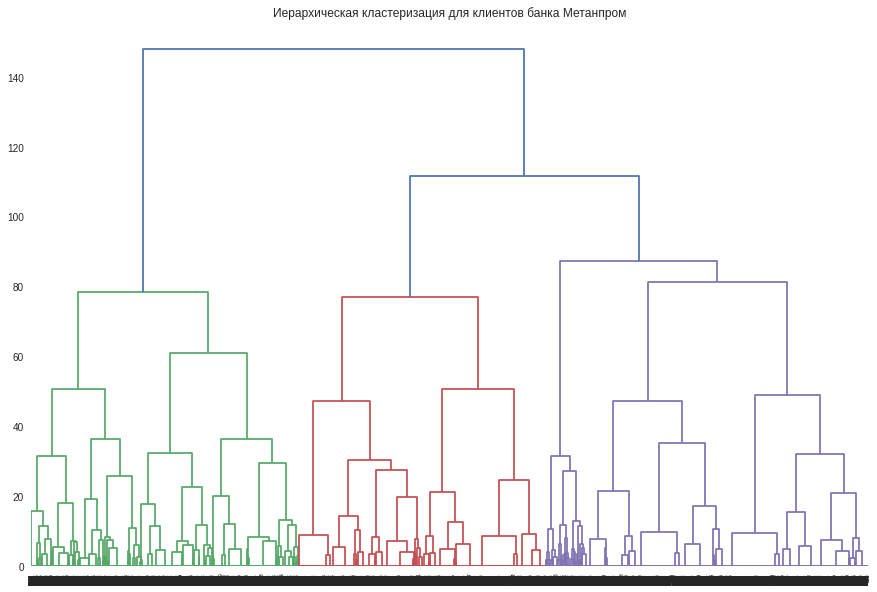

In [67]:
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top') #строим дендрограмму
plt.title('Иерархическая кластеризация для клиентов банка Метанпром')
plt.show()

На дендрограмме четко выделяются 3 кластера пользователей, как по цвету, так и по форме деревьев.

Зададим модель K-means с числом кластеров 3 и сохраним метки кластера в нашем датафрейме.

In [68]:
#зададим модель k-means с числом кластеров 3
km = KMeans(n_clusters=3, random_state=0)
#прогнозируем кластеры для наблюдений
labels = km.fit_predict(X_sc)
#сохраним метки кластера в поле нашего датафрейма
bank['cluster'] = labels

Попробуем оценить качество проведенной кластеризации. Для этого расчитаем метрику силуэта и сделаем вывод.

In [69]:
#посчитаем метрику силуэта для нашей кластеризации
print('Silhouette_score: {:.2f}'.format(silhouette_score(X_sc, labels)))

Silhouette_score: 0.24


Метрика силуэта для нашей кластеризации равна 0,24. Это не очень высокий показатель. Если бы кластерная структура была выражена хорошо, то метрика была бы близка к 1. Соответственна кластерная структура, получившаяся после проведения нами кластеризации, не выражена явно.

И все же попробуем описать каждый из трех сегментов, полученный при кластеризации.

In [70]:
#создадим переменную с сегментом 0
seg_0 = bank.query('cluster == 0')
#создадим переменную с сегментом 1
seg_1 = bank.query('cluster == 1')
#создадим переменную с сегментом 2
seg_2 = bank.query('cluster == 2')

Сделаем и выведем портрет сегмента 0.

In [71]:
#портрет клиента сегмента 0
seg_0_portrait = seg_0.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
seg_0_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
seg_0_portrait = seg_0_portrait.fillna('').T
seg_0_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 0',''),("Сегмент 0",'Среднее'),("Сегмент 0",'Медиана')])

display(seg_0_portrait)
print(f'Количество клиентов в сегменте 0: {len(seg_0)}')
print(f'Процент оттока в сегменте 0: {round(seg_0.churn.mean() * 100, 2)}%')

Сегмент 0                      
                                 Среднее    Медиана
Пол                         М                      
Город               Ярославль                      
Возраст                            41.91      39.00
Баланс                        863,973.77 575,806.62
Кредитный скоринг                 845.07     842.00
Доход                         124,788.75 106,130.71
Активность                                     0.00
Кредитная карта                                1.00
Продукты                                       2.00
Балл собственности                             4.00

Количество клиентов в сегменте 0: 3769
Процент оттока в сегменте 0: 22.05%


Опишем что представляет из себя каждый сегмент.

**Сегмент 0:**
- состоит в основном из мужчин
- средний возраст 41,91 года (медианный - 39 лет)
- из Ярославля
- средний балл скоринга 845,07  (медианный - 842)
- балл собственности 4
- средний баланс на счете 863973 рубля (медианный - 575806 рублей)
- **используемое число продуктов банка 2**
- 100% клиентов этого сегмента имеют кредитные карты
- **клиенты сегмента неактивны**
- средний доход 124788 рублей (медианный - 106130 рублей)
- **отток в сегменте составляет 22,05%**
- размер сегмента 3769 человек

In [72]:
#портрет клиента сегмента 1
seg_1_portrait = seg_1.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
seg_1_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
seg_1_portrait = seg_1_portrait.fillna('').T
seg_1_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 1',''),("Сегмент 1",'Среднее'),("Сегмент 1",'Медиана')])

display(seg_1_portrait)
print(f'Количество клиентов в сегменте 0: {len(seg_1)}')
print(f'Процент оттока в сегменте 0: {round(seg_1.churn.mean() * 100, 2)}%')

Сегмент 1                      
                                 Среднее    Медиана
Пол                         М                      
Город               Ярославль                      
Возраст                            41.98      40.00
Баланс                        327,003.81 223,479.43
Кредитный скоринг                 849.58     883.00
Доход                         186,261.66 145,628.58
Активность                                     1.00
Кредитная карта                                1.00
Продукты                                       1.00
Балл собственности                             0.00

Количество клиентов в сегменте 0: 3339
Процент оттока в сегменте 0: 5.24%


**Сегмент 1:**
- мужчины
- средний возраст 41,98 года (медианный - 40 лет)
- из Ярославля
- средний балл скоринга - 849,58 (медианный - 883)
- **балл собственности 0**
- средний баланс на счету клиента 327003 рубля (медианный - 223479 рублей)
- **количество продуктов 1**
- кредитные карты имеются у 100% клиентов
- **все активны**
- средний доход клиентов в сегменте 186261 рублей (медианный - 145628 рублей)
- **процент оттока составляет 5,24%**
- размер сегмента 3339 человек

In [73]:
#портрет клиента сегмента 2
seg_2_portrait = seg_2.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
seg_2_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
seg_2_portrait = seg_2_portrait.fillna('').T
seg_2_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 2',''),("Сегмент 2",'Среднее'),("Сегмент 2",'Медиана')])

display(seg_2_portrait)
print(f'Количество клиентов в сегменте 0: {len(seg_2)}')
print(f'Процент оттока в сегменте 0: {round(seg_2.churn.mean() * 100, 2)}%')

Сегмент 2                      
                                 Среднее    Медиана
Пол                         Ж                      
Город               Ярославль                      
Возраст                            44.67      42.00
Баланс                        993,867.72 643,386.90
Кредитный скоринг                 852.78     853.00
Доход                         133,549.91 112,326.76
Активность                                     1.00
Кредитная карта                                0.00
Продукты                                       2.00
Балл собственности                             4.00

Количество клиентов в сегменте 0: 2806
Процент оттока в сегменте 0: 28.72%


**Сегмент 2:**
- **женщины**
- средний возраст 44,67 лет (медианный - 42 года)
- из Ярославля
- средний балл скоринга - 852,78 (медианный - 853)
- балл собственности - 4
- средний баланс на счете 993867,72 рублей (медианный - 643386 рублей)
- **число продуктов используемых клиентов 2**
- **клиенты этого сегмента не имеют кредитных карт**
- клиенты активны
- средний доход клиентов 133549,91 рублей (медианный - 112326 рублей)
- **процент оттока в сегменте составляет 29,72%**
- размер сегмента 2806 клиентов 

Мы описали сегменты, полученные с помощью кластеризации. Можем сказать, что кластеризация не дала ожидаемых результатов по разделению на сегменты: в сегментах был невысокий отток, а в одном отток был ниже среднебанковского. Такой результат нельзя предъявлять заказчику. Хотя безусловно кластеризация дала понять, что те признаки, что мы выделили как влияющие на отток, действительно имеют влияние. Далее разделим клиентов на сегменты исходя из влияющих признаков.

### Выделение сегментов клиентов банка по признакам, влияющим на отток 

Выделим 3 сегмента клиентов банка, исходя из признаков, влияющих на отток. Далее сделаем их портреты и опишем.

#### Сегмент 1

Сегмент 1 будет включать в себя **мужчин с более, чем 2 продуктами**.

In [74]:
#выделим первый сегмент
s1 = bank.query('gender == "М" & products > 2')

Составим общий портрет пользователей сегмента 1.

In [75]:
#портрет клиента сегмента 1
s1_portrait = s1.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s1_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s1_portrait = s1_portrait.fillna('').T
s1_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 1',''),("Сегмент 1",'Среднее'),("Сегмент 1",'Медиана')])

display(s1_portrait)
print(f'Количество клиентов в сегменте 1: {len(s1)}')
print(f'Процент оттока в сегменте 1: {round(s1.churn.mean() * 100, 2)}%')

Сегмент 1                        
                                   Среднее    Медиана
Пол                         М                        
Город               Ярославль                        
Возраст                              40.74      39.00
Баланс                        1,209,357.89 746,996.62
Кредитный скоринг                   854.03     852.50
Доход                           146,233.39 116,625.70
Активность                                       1.00
Кредитная карта                                  1.00
Продукты                                         3.00
Балл собственности                               4.00

Количество клиентов в сегменте 1: 746
Процент оттока в сегменте 1: 50.27%


Выведем клиентов сегмента 1.

In [76]:
#выводим клиентов первого сегмента
display(s1.drop(columns=['М', 'Ж', 'Ярославль', 'Ростов', 'Рыбинск', 'cluster']).head())

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
5,202305,856,Рыбинск,М,56,4,"863,687.24",3,1,0,"156,619.80",0
15,120260,731,Рыбинск,М,42,3,"1,480,548.47",3,1,0,"160,974.43",0
72,156677,873,Ярославль,М,39,5,"915,959.85",3,0,1,"154,034.62",1
81,223978,850,Рыбинск,М,34,5,"351,583.16",4,0,1,"115,354.97",1
95,172823,855,Ярославль,М,41,1,"312,743.28",3,0,0,"268,100.87",0


**Общий портрет сегмента 1:**
- Мужчины
- в основном из Ярославля
- в среднем около 40 лет
- имеют средний баланс на счете 1209357 рублей
- средний кредитный скоринг 854 балла
- средний доход 146233 рубля
- активные
- большинство имеют кредитную карту
- пользуются в среднем 3 продуктами
- имеют балл собственности 4
- размер сегмента 746 клиентов
- процент оттока 50,27%

#### Сегмент 2

Сегмент 2 будет включать в себя **клиентов без кредитной карты с более чем 2 баллами собственности**.

In [77]:
#выделим второй сегмент
s2 = bank.query('credit_card == 0 & equity > 2')

Составим общий портерт клиентов второго сегмента.

In [78]:
#портрет клиента сегмента 2
s2_portrait = s2.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s2_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s2_portrait = s2_portrait.fillna('').T
s2_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 2',''),("Сегмент 2",'Среднее'),("Сегмент 2",'Медиана')])

display(s2_portrait)
print(f'Количество клиентов в сегменте 2: {len(s2)}')
print(f'Процент оттока в сегменте 2: {round(s2.churn.mean() * 100, 2)}%')

Сегмент 2                        
                                   Среднее    Медиана
Пол                         Ж                        
Город               Ярославль                        
Возраст                              44.57      42.00
Баланс                        1,152,093.80 781,680.08
Кредитный скоринг                   858.58     860.00
Доход                           137,744.68 114,738.29
Активность                                       1.00
Кредитная карта                                  0.00
Продукты                                         2.00
Балл собственности                               4.00

Количество клиентов в сегменте 2: 2125
Процент оттока в сегменте 2: 33.18%


Выведем клиентов второго сегмента.

In [79]:
#выводим клиентов второго сегмента
display(s2.drop(columns=['М', 'Ж', 'Ярославль', 'Ростов', 'Рыбинск', 'cluster']).head())

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
3,225363,866,Ярославль,Ж,51,5,"1,524,746.26",2,0,1,"174,423.53",1
6,177259,807,Ярославль,Ж,39,3,"405,042.44",3,0,1,"103,838.32",0
13,166357,837,Рыбинск,Ж,28,4,"302,249.22",2,0,1,"30,950.94",0
18,136651,876,Ярославль,М,40,5,"2,307,947.36",2,0,0,"287,010.61",0
20,114192,772,Ростов,М,43,3,"1,315,511.65",2,0,0,"143,935.71",0


**Общий портрет сегмента 2:**
- в основном женщины
- по большей части из Ярославля
- в возрасте около 44 лет
- имеют средний баланс на счете 1152093 рублей
- со средним кредитным скорингом в 858 баллов
- средний доход 137744 рублей
- активные
- в основном не имеют кредитных карт
- пользуются по большей части 2 продуктами
- имеют балл собственности 4
- размер сегмента 2125 клиентов
- процент оттока по сегменту 33,18%

#### Сегмент 3

Третий сегмент будет состоять из **активных клиентов с балансом более 1200000 рублей**.

In [80]:
#выделим третий сегмент
s3 = bank.query('last_activity == 1 & balance > 1200000')

Составим общий портрет клиентов второго сегмента.

In [81]:
#портрет клиента сегмента 3
s3_portrait = s3.agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s3_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s3_portrait = s3_portrait.fillna('').T
s3_portrait.columns=pd.MultiIndex.from_tuples([('Сегмент 3',''),("Сегмент 3",'Среднее'),("Сегмент 3",'Медиана')])

display(s3_portrait)
print(f'Количество клиентов в сегменте 3: {len(s3)}')
print(f'Процент оттока в сегменте 3: {round(s3.churn.mean() * 100, 2)}%')

Сегмент 3                          
                                   Среднее      Медиана
Пол                         М                          
Город               Ярославль                          
Возраст                              45.75        43.00
Баланс                        2,620,355.66 1,532,045.97
Кредитный скоринг                   882.50       892.00
Доход                           210,136.90   157,017.86
Активность                                         1.00
Кредитная карта                                    0.00
Продукты                                           2.00
Балл собственности                                 4.00

Количество клиентов в сегменте 3: 705
Процент оттока в сегменте 3: 56.17%


Выведем клиентов третьего сегмента.

In [82]:
#выводим клиентов третьего сегмента
display(s3.drop(columns=['М', 'Ж', 'Ярославль', 'Ростов', 'Рыбинск', 'cluster']).head())

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
3,225363,866,Ярославль,Ж,51,5,"1,524,746.26",2,0,1,"174,423.53",1
35,221927,863,Ростов,М,39,5,"1,461,423.33",1,0,1,"221,699.52",0
36,199614,822,Ярославль,М,60,5,"1,472,483.77",1,1,1,"89,132.67",0
74,222208,950,Рыбинск,Ж,43,4,"2,332,677.14",2,1,1,"301,845.59",0
76,213688,922,Ярославль,Ж,37,5,"1,214,707.38",4,0,1,"85,121.07",0


**Общий портрет сегмента 3:**
- в основном мужчины
- из города Ярославль в большинстве
- возраст около 45 лет
- имеют на счету в среднем 2620355 рубля
- средний кредитный скоринг 882 балла
- со средним доходом в 210136 рублей
- активные
- большинство не имеют кредитных карт
- пользуются по большей части 2 продуктами банка
- в большинстве имеют балл собственности 4
- размер сегмента 705 клиентов
- процент оттока по сегменту 56,17%

#### Портреты клиентов, склонных к оттоку, по сегментам

Составим портреты отточных клиентов по сегментам.

In [83]:
#портрет отточного клиента сегмента 1
s1_churn_portrait = s1.query('churn == 1').agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s1_churn_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s1_churn_portrait = s1_churn_portrait.fillna('').T
s1_churn_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 1 отток',''),("Сегмент 1 отток",'Среднее'),("Сегмент 1 отток",'Медиана')])

#портрет отточного клиента сегмента 2
s2_churn_portrait = s2.query('churn == 1').agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s2_churn_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s2_churn_portrait = s2_churn_portrait.fillna('').T
s2_churn_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 2 отток',''),("Сегмент 2 отток",'Среднее'),("Сегмент 2 отток",'Медиана')])

#портрет отточного клиента сегмента 3
s3_churn_portrait = s3.query('churn == 1').agg({'gender': 'mode',
                                 'city': 'mode',
                                 'age': ['median', 'mean'],
                                 'balance': ['median', 'mean'],
                                 'score': ['median', 'mean'],
                                 'est_salary': ['median', 'mean'],
                                 'last_activity': 'median',
                                 'credit_card': 'median',
                                 'products': 'median',
                                 'equity': 'median'})
s3_churn_portrait.columns=['Пол', 'Город', 'Возраст', 'Баланс','Кредитный скоринг', 'Доход', 'Активность', 'Кредитная карта', 'Продукты', 'Балл собственности']
s3_churn_portrait = s3_churn_portrait.fillna('').T
s3_churn_portrait.columns=pd.MultiIndex.from_tuples( [('Сегмент 3 отток',''),("Сегмент 3 отток",'Среднее'),("Сегмент 3 отток",'Медиана')])

#объединяем
all_segments_portrait = pd.merge(s1_churn_portrait, s2_churn_portrait, left_index=True, right_index=True)
all_segments_portrait = pd.merge(all_segments_portrait, s3_churn_portrait, left_index=True, right_index=True)
#выводим
display(all_segments_portrait)

Сегмент 1 отток                           Сегмент 2 отток  \
                                        Среднее      Медиана                   
Пол                              М                                         М   
Город                    Ярославль                                 Ярославль   
Возраст                                   41.49        39.00                   
Баланс                             1,380,657.08 1,134,652.58                   
Кредитный скоринг                        869.75       874.00                   
Доход                                164,664.46   137,392.41                   
Активность                                              1.00                   
Кредитная карта                                         1.00                   
Продукты                                                4.00                   
Балл собственности                                      4.00                   

                                             Сегмент 3 отток               \
                        Среднее      Медиана                      Среднее   
Пол                                                        М                
Город                                              Ярославль                
Возраст                   41.81        39.00                        43.02   
Баланс             1,393,782.01 1,100,643.27                 2,510,137.58   
Кредитный скоринг        880.37       883.00                       894.83   
Доход                158,616.62   133,963.72                   227,411.66   
Активность                              1.00                                
Кредитная карта                         0.00                                
Продукты                                2.00                                
Балл собственности                      4.00                                

                                 
                        Медиана  
Пол                              
Город                            
Возраст                   40.00  
Баланс             1,688,178.19  
Кредитный скоринг        899.00  
Доход                175,387.58  
Активность                 1.00  
Кредитная карта            0.00  
Продукты                   2.00  
Балл собственности         4.00

Отточные клиенты сегмента 1 имеют самый низкий балл кредитного скоринга, у большинства есть кредитная карта и пользуются 4 продуктами банка.

Отточные клиенты сегмента 2 имеют наименьший доход, по большей части не обладают кредитными картами и пользуются 2 продуктами.

Отточные клиенты сегмента 3 имеют наивысший баланс на счету и доход, самый высокий балл кредитного скоринга среди сегментов, в большинстве не имеют кредитных карт и пользуются 2 продуктами.

### Распределение признаков по сегментам

Посмотрим как распределились признаки по трем выделенным сегментам.

Посмотрим первый признак - балл кредитного скоринга.

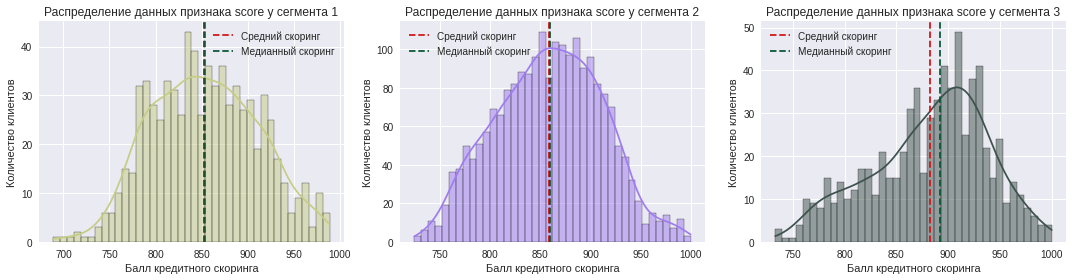

In [84]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака score для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.histplot(s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='score', bins=40, kde=True, color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака score у сегмента 1")
plt.axvline(s1['score'].mean(), color='#d41212', linestyle='--', label = 'Средний скоринг')
plt.axvline(s1['score'].median(), color='#065535', linestyle='--', label = 'Медианный скоринг')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('Балл кредитного скоринга')

#строим гистограмму с распределением признака score для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.histplot(s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='score', bins=40, kde=True, color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака score у сегмента 2")
plt.axvline(s2['score'].mean(), color='#d41212', linestyle='--', label = 'Средний скоринг')
plt.axvline(s2['score'].median(), color='#065535', linestyle='--', label = 'Медианный скоринг')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('Балл кредитного скоринга')

#строим гистограмму с распределением признака score для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.histplot(s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='score', bins=40, kde=True, color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака score у сегмента 3")
plt.axvline(s3['score'].mean(), color='#d41212', linestyle='--', label = 'Средний скоринг')
plt.axvline(s3['score'].median(), color='#065535', linestyle='--', label = 'Медианный скоринг')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('Балл кредитного скоринга')

plt.tight_layout()
plt.show()

Кредитный скоринг сегмента 1 находится в основном в диапазоне от 775 до 925 баллов. У сегмента 2 распределение приходится на диапазон от 725 до 950 баллов. У сегмента 3 основное распределение баллов приходится на диапазон от 755 до 950 баллов, с пиками в диапазоне 860 - 930 баллов.

Теперь посмотрим как распределились города по сегментам.

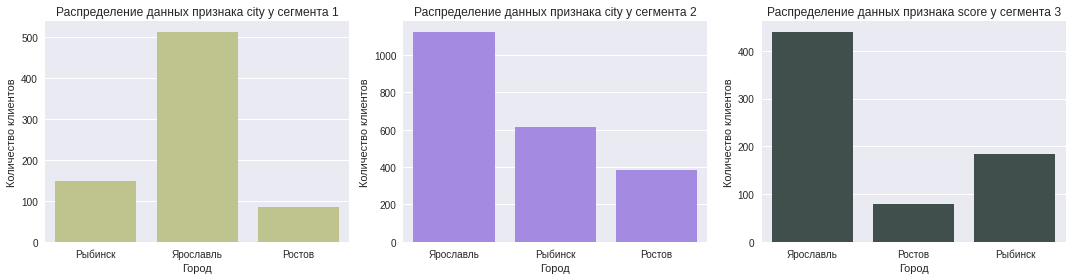

In [85]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака city для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data = s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='city', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака city у сегмента 1")
plt.ylabel('Количество клиентов')
plt.xlabel('Город')

#строим гистограмму с распределением признака score для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='city', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака city у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Город')

#строим гистограмму с распределением признака city для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='city', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака score у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Город')

plt.tight_layout()
plt.show()

Распределение городов по сегментам выглядят примерно одинаково. Во всех сегментах лидирует Ярославль, далее идет Рыбинск и замыкает тройку Ростов.

Рассмотрим распределение клиентов по полам в каждом сегменте.

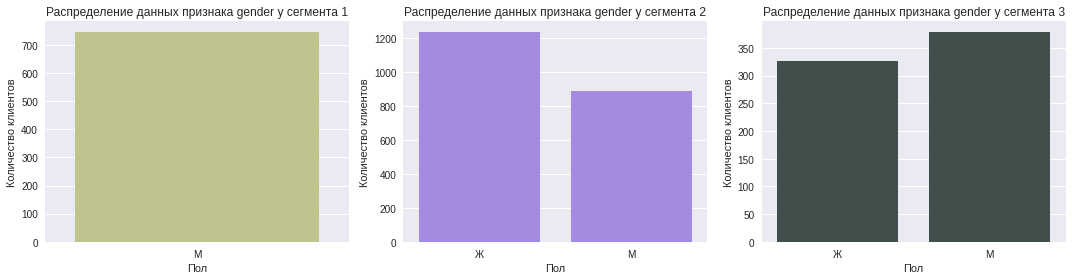

In [86]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака gender для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='gender', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака gender у сегмента 1")
plt.ylabel('Количество клиентов')
plt.xlabel('Пол')

#строим гистограмму с распределением признака gender для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='gender', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака gender у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Пол')

#строим гистограмму с распределением признака gender для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='gender', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака gender у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Пол')

plt.tight_layout()
plt.show()

В сегменте 1 представлены только мужчины. В сегменте 2 количество женщин превышает количество мужчин. А в сегменте 3 количество мужчин превышает количество женщин.

Посмотрим распределения возраста в каждом сегменте.

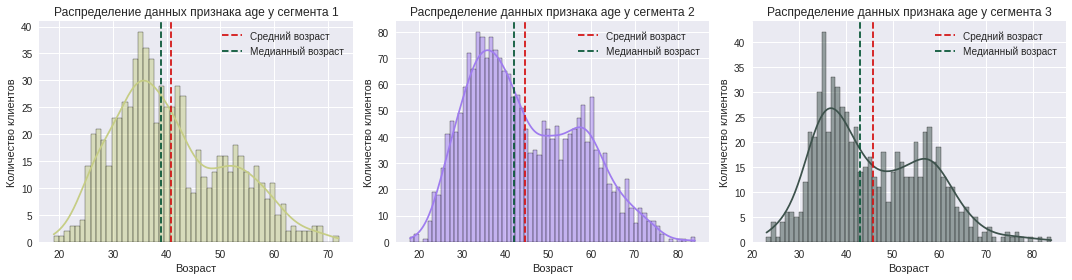

In [87]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака age для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.histplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='age', kde=True, bins=54, color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака age у сегмента 1")
plt.axvline(s1['age'].mean(), color='#d41212', linestyle='--', label = 'Средний возраст')
plt.axvline(s1['age'].median(), color='#065535', linestyle='--', label = 'Медианный возраст')
plt.legend()
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')

#строим гистограмму с распределением признака age для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.histplot(s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='age', kde=True, bins=65, color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака age у сегмента 2")
plt.axvline(s2['age'].mean(), color='#d41212', linestyle='--', label = 'Средний возраст')
plt.axvline(s2['age'].median(), color='#065535', linestyle='--', label = 'Медианный возраст')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('Возраст')

#строим гистограмму с распределением признака age для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.histplot(s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='age', kde=True, bins=62, color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака age у сегмента 3")
plt.axvline(s3['age'].mean(), color='#d41212', linestyle='--', label = 'Средний возраст')
plt.axvline(s3['age'].median(), color='#065535', linestyle='--', label = 'Медианный возраст')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('Возраст')

plt.tight_layout()
plt.show()

Распределение возраста в трех сегментов похоже. В первом сегменте прелбладают клиенты в возрасте 30-42 лет, во втором - 25-45 лет, в третьем - 32-42 года и есть всплеск в области 55-60 лет.

Посмотрим распределение баллов собственности по сегментам.

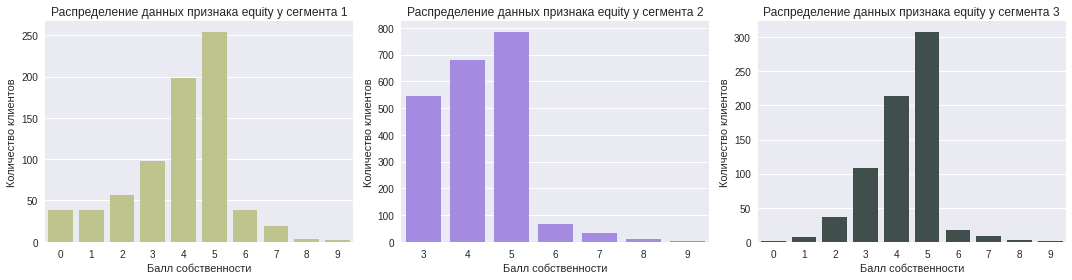

In [88]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака equity для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='equity', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака equity у сегмента 1")
plt.ylabel('Количество клиентов')
plt.xlabel('Балл собственности')

#строим гистограмму с распределением признака equity для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='equity', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака equity у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Балл собственности')

#строим гистограмму с распределением признака equity для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='equity', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака equity у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Балл собственности')

plt.tight_layout()
plt.show()

Распределение баллов собственности у трех сегментов схоже. За исключением сегмента 2, там баллы в диапазоне 3-9, но это заданная нами особенность сегмента. В общем, во всех сегментах больше всего клиентов с 4 и 5 баллами собственности.

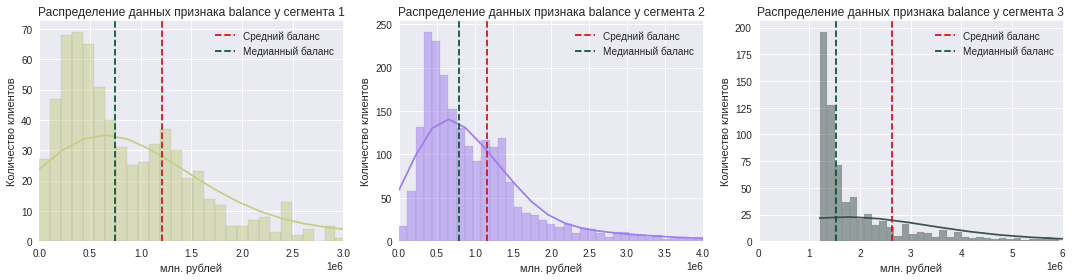

In [89]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака balance для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.histplot(s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='balance', kde=True, bins=400, color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака balance у сегмента 1")
plt.axvline(s1['balance'].mean(), color='#d41212', linestyle='--', label = 'Средний баланс')
plt.axvline(s1['balance'].median(), color='#065535', linestyle='--', label = 'Медианный баланс')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('млн. рублей')
plt.xlim(0, 3000000)

#строим гистограмму с распределением признака balance для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.histplot(s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='balance', kde=True, bins=400, color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака balance у сегмента 2")
plt.axvline(s2['balance'].mean(), color='#d41212', linestyle='--', label = 'Средний баланс')
plt.axvline(s2['balance'].median(), color='#065535', linestyle='--', label = 'Медианный баланс')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('млн. рублей')
plt.xlim(0, 4000000)

#строим гистограмму с распределением признака balance для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.histplot(s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='balance', kde=True, bins=800, color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака balance у сегмента 3")
plt.axvline(s3['balance'].mean(), color='#d41212', linestyle='--', label = 'Средний баланс')
plt.axvline(s3['balance'].median(), color='#065535', linestyle='--', label = 'Медианный баланс')
plt.legend()
plt.ylabel('Количество клиентов')
plt.xlabel('млн. рублей')
plt.xlim(0, 6000000)

plt.tight_layout()
plt.show()

Баланс клиентов сегмента 1 распределен по большей части в диапазоне от 100 тыс. до 1,4 млн. рублей, с пиком в области 200-500 тыс рублей.

Баланс клиентов в сегменте 2 в основном распределен в диапазоне от 250 тыс. до 1,5 млн. рублей, с пиком в области 400-500 тыс. рублей.

Баланс основной части клиентов, попавших в сегмент 3, распределен в диапазоне от 1,2 - 1,6 млн. рублей, с пиком в области 1,2 млн. рублей. Стоит отметить, что в сегенте 3 баланс начинается от 1,2 млн. рублей - это введенная нами особенность сегмента.

Посмотрим распределение количества продуктов в каждом сегменте.

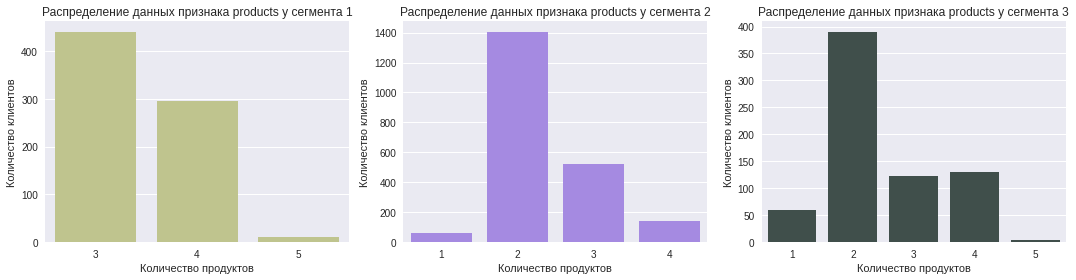

In [90]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака products для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='products',  color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака products у сегмента 1")
plt.ylabel('Количество клиентов')
plt.xlabel('Количество продуктов')

#строим гистограмму с распределением признака products для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='products', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака products у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Количество продуктов')

#строим гистограмму с распределением признака products для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='products', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака products у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Количество продуктов')

plt.tight_layout()
plt.show()

По количеству продуктов получилось разное распределение у сегментов.

У сегмента 1 больше всего клиентов с 3-мя продуктами. В сегменте 1 представлены только клиенты, у которых более 2 баллов собственности - это одна из особенностей сегмента.

В сегменте 2 и 3 представлены клиенты по большей части с 2-мя продуктами. В сегмент 3 также входят клиенты с 5-ю продуктами, которые не входят во 2 сегмент.

Посмотрим распределение наличия кредитной карты у клиентов по сегментам.

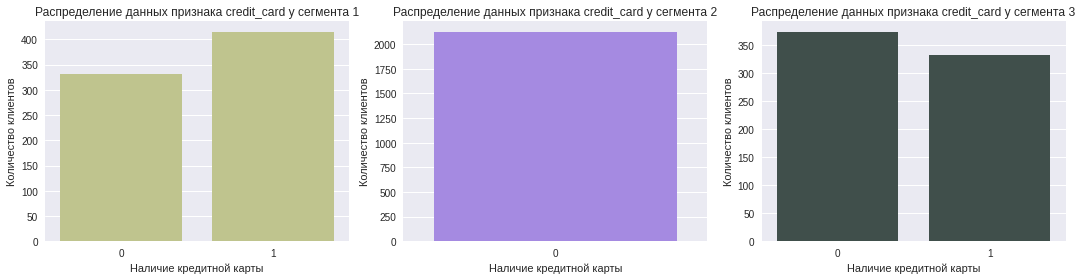

In [91]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака credit_card для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='credit_card', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака credit_card у сегмента 1")
plt.xlabel('Наличие кредитной карты')
plt.ylabel('Количество клиентов')

#строим гистограмму с распределением признака credit_card для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='credit_card', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака credit_card у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Наличие кредитной карты')

#строим гистограмму с распределением признака credit_card для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='credit_card', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака credit_card у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Наличие кредитной карты')

plt.tight_layout()
plt.show()

В сегменте 1 находится больше клиентов с кредитной картой; в сегменте 2 - только клиенты, не имеющие кредитную карту; среди клиентов сегмента 3 больше клиентов без кредитной карты, но также присутствуют и с картой.

Посмотрим распределение активности клиентов по сегментам.

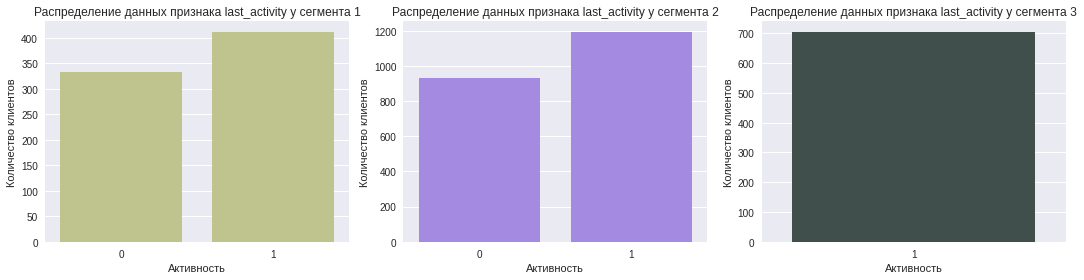

In [92]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака last_activity для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='last_activity', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака last_activity у сегмента 1")
plt.xlabel('Активность')
plt.ylabel('Количество клиентов')

#строим гистограмму с распределением признака last_activity для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='last_activity', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака last_activity у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Активность')

#строим гистограмму с распределением признака last_activity для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='last_activity', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака last_activity у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Активность')

plt.tight_layout()
plt.show()

В 1 и 2 сегментах преобладают активные клиенты. В 3 сегменте присутствуют только активные - это особенность сегмента.

Теперь посмотрим как распределен самый важный для нас показатель - отток.

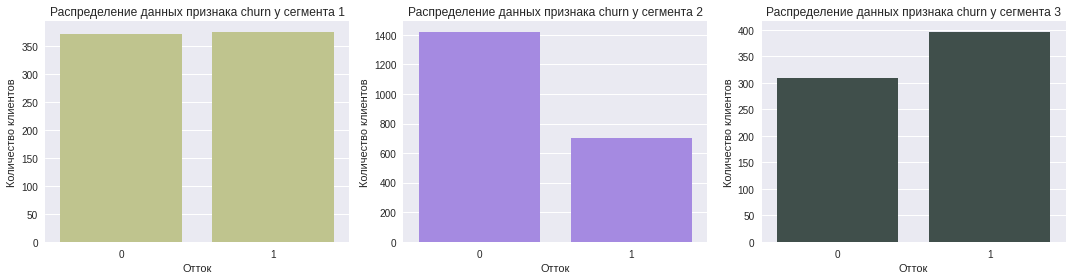

In [93]:
#plt.style.use('seaborn')
plt.figure(figsize=(15, 4))
#строим гистограмму с распределением признака churn для сегмента 1
ax1 = plt.subplot(1, 3, 1)
sns.countplot(data=s1.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='churn', color='#C6CD85', ax=ax1)
plt.title(f"Распределение данных признака churn у сегмента 1")
plt.xlabel('Отток')
plt.ylabel('Количество клиентов')

#строим гистограмму с распределением признака churn для сегмента 2
ax2 = plt.subplot(1, 3, 2)
sns.countplot(data=s2.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='churn', color='#9F7CEF', ax=ax2)
plt.title(f"Распределение данных признака churn у сегмента 2")
plt.ylabel('Количество клиентов')
plt.xlabel('Отток')

#строим гистограмму с распределением признака churn для сегмента 3
ax3 = plt.subplot(1, 3, 3)
sns.countplot(data=s3.drop(columns=['user_id', 'cluster', 'М', 'Ж', 'Ростов', 'Рыбинск', 'Ярославль']), x='churn', color='#3D524C', ax=ax3)
plt.title(f"Распределение данных признака churn у сегмента 3")
plt.ylabel('Количество клиентов')
plt.xlabel('Отток')

plt.tight_layout()
plt.show()

В 1 сегменте оставшиеся и отточные клиенты распределены примерно одинаково, но отточных немного больше. Во 2 сегменте больше оставшихся пользователей почти в 2 раза. В третьем - больше клиентов в оттоке.

### Приоритизация клиентских сегентов

После анализа признаков по каждому сегменту, посмотрим, на какой сегмент стоит обратить больше всего внимания отделу маркетинга для дальнейшей работы.

In [94]:
#считаем метрики для сегмента 1
s1_churn_vol = s1.agg({'churn': ['count', 'sum', 'mean']}).T
s1_churn_vol.rename(index={'churn': 'Сегмент 1'}, inplace=True)
s1_churn_vol.style.format({'mean': '{:.1%}'})

#считаем метрики для сегмента 2
s2_churn_vol = s2.agg({'churn': ['count', 'sum', 'mean']}).T
s2_churn_vol.rename(index={'churn': 'Сегмент 2'}, inplace=True)

#считаем метрики для сегмента 3
s3_churn_vol = s3.agg({'churn': ['count', 'sum', 'mean']}).T
s3_churn_vol.rename(index={'churn': 'Сегмент 3'}, inplace=True)

#объединяем
prioritized_segment = pd.concat([s1_churn_vol, s2_churn_vol, s3_churn_vol])
prioritized_segment.columns = ['Общее количество клиентов', 'Количество ушедших клиентов', '% оттока']
prioritized_segment['% оттока'] = round(prioritized_segment['% оттока'] * 100, 2)
prioritized_segment['% оттока'] = prioritized_segment['% оттока'].astype(str) + "%"

prioritized_segment

,Общее количество клиентов,Количество ушедших клиентов,% оттока
Сегмент 1,746.00,375.00,50.27%
Сегмент 2,"2,125.00",705.00,33.18%
Сегмент 3,705.00,396.00,56.17%


Наблюдаем, что самый низкий процент оттока во 2 сегменте - 33,18%, далее идет сегмент 1 - 50,27%, самый высокий процент оттока в сегменте 3 - 56,17%. 

Но мы так же видим, что сегменты отличаются размерами и количеством ушедших клиентов. Поэтому для приоритизации сегментов будем ориентироваться на общее количество клиентов и количество ушедших клиентов.

Больше всего ушедших клиентов (705) в сегменте 2, также этот сегмент самый большой по количеству клиентов - поставим его на 1 место. На 2 место поставим сегмент 3 - несмотря на то, что в нем наименьшее количество клиентов, зато в нем больше ушедших клиентов (396). Ну и на 3 место поставим сегмент 1 с 375 ушедшими клиентами.

Таким образом, **важность сегментов** распределилась так:
1. Сегмент 2
2. Сегмент 3
3. Сегмент 1

**Вывод по разделу:**

В рамках данного раздела мы выделили 3 сегмента клиентов.

**Сегмент 1** (принцип форимирования - мужчины с более, чем 2-мя продуктами в пользовании):
- Мужчины
- в основном из Ярославля
- в среднем около 40 лет
- имеют средний баланс на счете 1209357 рублей
- средний кредитный скоринг 854 балла
- средний доход 146233 рубля
- активные
- большинство имеют кредитную карту
- пользуются в среднем 3 продуктами
- имеют балл собственности 4
- размер сегмента 746 клиентов
- процент оттока 50,27%

**Сегмент 2** (принцип формирования - клиенты без кредитной карты с баллами собствености более 2-ух):
- в основном женщины
- по большей части из Ярославля
- в возрасте около 44 лет
- имеют средний баланс на счете 1152093 рублей
- со средним кредитным скорингом в 858 баллов
- средний доход 137744 рублей
- активные
- в основном не имеют кредитных карт
- пользуются по большей части 2 продуктами
- имеют балл собственности 4
- размер сегмента 2125 клиентов
- процент оттока по сегменту 33,18%

**Сегмент 3** (принцип формирования - активные клиенты с балансом более 1200000 рублей):
- в основном мужчины
- из города Ярославль в большинстве
- возраст около 45 лет
- имеют на счету в среднем 2620355 рубля
- средний кредитный скоринг 882 балла
- со средним доходом в 210136 рублей
- активные
- большинство не имеют кредитных карт
- пользуются по большей части 2 продуктами банка
- в большинстве имеют балл собственности 4
- размер сегмента 705 клиентов
- процент оттока по сегменту 56,17%

Отточные клиенты сегмента 1 имеют самый низкий балл кредитного скоринга, у большинства есть кредитная карта и пользуются 4 продуктами банка.

Отточные клиенты сегмента 2 имеют наименьший доход, по большей части не обладают кредитными картами и пользуются 2 продуктами.

Отточные клиенты сегмента 3 имеют наивысший баланс на счету и доход, самый высокий балл кредитного скоринга среди сегментов, в большинстве не имеют кредитных карт и пользуются 2 продуктами.

Посмотрели распределения признаков по каждому сегменту:
- Кредитный скоринг сегмента 1 находится в основном в диапазоне от 775 до 925 баллов. У сегмента 2 распределение приходится на диапазон от 725 до 950 баллов. У сегмента 3 основное распределение баллов приходится на диапазон от 755 до 950 баллов, с пиками в диапазоне 860 - 930 баллов.
- Распределение городов по сегментам примерно одинаково. Во всех сегментах лидирует Ярославль, далее идет Рыбинск и замыкает тройку Ростов.
- В сегменте 1 представлены только мужчины. В сегменте 2 количество женщин превышает количество мужчин. А в сегменте 3 количество мужчин превышает количество женщин.
- Распределение возраста в трех сегментов похоже. В первом сегменте прелбладают клиенты в возрасте 30-42 лет, во втором - 25-45 лет, в третьем - 32-42 года и есть всплеск в области 55-60 лет.
- Распределение баллов собственности у трех сегментов схоже. За исключением сегмента 2, там баллы в диапазоне 3-9, но это заданная нами особенность сегмента. В общем, во всех сегментах больше всего клиентов с 4 и 5 баллами собственности.
- Баланс клиентов сегмента 1 распределен по большей части в диапазоне от 100 тыс. до 1,4 млн. рублей, с пиком в области 200-500 тыс рублей. Баланс клиентов в сегменте 2 в основном распределен в диапазоне от 250 тыс. до 1,5 млн. рублей, с пиком в области 400-500 тыс. рублей. Баланс основной части клиентов, попавших в сегмент 3, распределен в диапазоне от 1,2 - 1,6 млн. рублей, с пиком в области 1,2 млн. рублей. Стоит отметить, что в сегенте 3 баланс начинается от 1,2 млн. рублей - это введенная нами особенность сегмента.
- У сегмента 1 больше всего клиентов с 3-мя продуктами. В сегменте 1 представлены только клиенты, у которых более 2 баллов собственности - это одна из особенностей сегмента. В сегменте 2 и 3 представлены клиенты по большей части с 2-мя продуктами. В сегмент 3 также входят клиенты с 5-ю продуктами, которые не входят во 2 сегмент.
- В сегменте 1 находится больше клиентов с кредитной картой; в сегменте 2 - только клиенты, не имеющие кредитную карту; среди клиентов сегмента 3 больше клиентов без кредитной карты, но также присутствуют и с картой.
- В 1 и 2 сегментах преобладают активные клиенты. В 3 сегменте присутствуют только активные - это особенность сегмента.
- В 1 сегменте оставшиеся и отточные клиенты распределены примерно одинаково, но отточных немного больше. Во 2 сегменте больше оставшихся пользователей почти в 2 раза. В третьем - больше клиентов в оттоке.

Самый низкий процент оттока во 2 сегменте - 33,18%, далее идет сегмент 1 - 50,27%, самый высокий процент оттока в сегменте 3 - 56,17%. Так как размерых сегментов неравномерны, приоритизацию проводили исходя из общего количества клиентов и количества ушедших клиентов.

**Приоритет сегментов:**
1. Сегмент 2 (705 ушедших)
2. Сегмент 3 (396 ушедших)
3. Сегмент 1 (375 ушедших)

## Выводы и рекомендации

Мы провели исследование по анализу оттока клиентов банка «Метанпром».

В начале исследования мы посмотрели общую информацию о данных и сделали их предобработку для более удобного и корректного анализа.

В рамках исследовательского анализа выяснили, что **процент клиентов в оттоке составляет 18,3%, а оставшихся 81,7% от общего числа всех клиентов**.

Составили **общий портрет отточного клиента**:
- мужчина
- в основном из Ярославля
- со средним возрастом в 41,42 года
- активный
- со средним доходом в 148358 рублей
- средний баланс на счету 1135552 рубля
- имеет кредитную карту
- пользуется 2 продуктами
- медианный балл собственности 4
- средний балл кредитного скоринга 863,5

Построили распределения признаков в разрезе по оттоку и вот какие важные взаимосвязи нам удалось обнаружить:
- Отток превышает лояльность в диапазоне баллов кредитного скоринга от 820 до 910. Слабое влияние этого признака на отток вероятно.
- Данные по Рыбинску лежат ниже среднего значения оттока по банку, в то время как данные по Ярославлю и Ростову немного превышают этот показатель. Тут речь идет об очень слабом влиянии города на отток.
- Данные по женщинам лежат ниже среднего значения оттока по банку, в то время как данные по мужчинам, наоборот, лежат выше. Влияние пола на отток прослеживается, причем чаще отваливаются мужчины.
- Данные по возрасту клиентов в оттоке в некоторых диапазонах находятся выше лояльных клиентов. Такие превышения мы видим в области 21 года, 25-35 лет, 50-60 лет. Видимо, кдиенты такого возраста попадают в отток чаще. Некоторое влияние возраста на отток может присутствовать.
- Данные по баллам собственности в диапазоне от 3 до 9 лежат выше среднего оттока по банку, что говорит о влиянии данного признака на отток.
- Примерно с 1,2 млн рублей на балансе у клиентов отток начинает превышать лояльность. Исходя из этого можно предположить, что при большем балансе на счету, клиенты менее склонны к оттоку. Некая зависимость оттока от баланса скорее всего может присутствовать.
- Все данные по количеству продуктов лежат выше среднего оттока по банку, за исключением 1 продукта. Больше всего к оттоку склонны клиенты с 4 продуктами. Влияние количества продуктов на отток явно прослеживается.
- Данные с клиентами без кредитной карты лежат выше среднего значения оттока по банку, в то время как данные с клиентами, имеющими кредитку, лежат ниже. Это указывает на некое влияние отсутствия кредитной карты на отток. Клиенты без кредитной карты попадают в отток чаще.
- Активные клиенты находятся выше среднего значения оттока по банку, а неактивные наоборот. Чаще в отток попадают активные клиенты. Данный показатель имеет влияние на отток.
- Превышение оттока в доходах прослеживается в области от примерно 100 тыс. до 200 тыс. рублей, далее превышение идет с чередованием. Нельзя четко говорить о влиянии дохода на отток, если только о слабом.

Построив матрицу корреляций, выяснили, что такие принаки как **пол, баллы собственности, активность клиентов, количество продуктов и наличие кредитной карты** слабо, но больше всех остальных признаков влияют на отток.

Для подтверждения предположений выдвинутых в ходе исследовательского анализа, проверили 6 гипотез (первая была предоставлена нам заказчиком).
В ходе проверки гипотез мы подтвердили наши предположения:
- Есть разница в доходах у оставшихся и отточных клиентов, она совсем небольшая (472 рубля). Но говорить о влиянии данного признака на отток все же сомнительно.
- Есть различие в среднем балле собственности у отточных и оставшихся клиентов. У клиентов в оттоке составил 3,77, а оставшихся - 2,38. В отток попадают клиенты с бОльшим баллом собственности.
- Есть отличие в среднем количестве продуктов у оставшихся и отточных клиентов. У клиентов в оттоке составляет 2,38, а у оставшихся - 1,76. В оттоке клиенты с бОльшим средним количеством продуктов.
- Есть различия в наличии кредитных карт у пользователей двух групп. Среди клиентов в оттоке кредитные карты есть у 55% клиентов, а среди оставшихся - у 71% клиентов. Есть некое влияние отсутствия креитной карты на попадание в отток.
- Прослеживается разница в активности у отточных и оставшихся клиентов. В среднем около 70% клиентов среди отточных активны, в то время как среди оставшихся активны 48%. Есть влияние активности клиента на попадание его в отток.
- Обнаружено различие в соотношении мужчин в двух группах. Среди клиентов в оттоке 65% мужчин, а среди оставшихся - 47%. Это подтверждает наше предположение о том, что мужчины чаще попадают в отток.

Далее мы провели сегментацию клиентов банка и выделили 3 сегмента со следующими характеристиками.

**Сегмент 1** (принцип форимирования - мужчины с более, чем 2-мя продуктами в пользовании):
- Мужчины
- в основном из Ярославля
- в среднем около 40 лет
- имеют средний баланс на счете 1209357 рублей
- средний кредитный скоринг 854 балла
- средний доход 146233 рубля
- активные
- большинство имеют кредитную карту
- пользуются в среднем 3 продуктами
- имеют балл собственности 4
- размер сегмента 746 клиентов
- процент оттока 50,27%

**Сегмент 2** (принцип формирования - клиенты без кредитной карты с баллами собствености более 2-ух):
- в основном женщины
- по большей части из Ярославля
- в возрасте около 44 лет
- имеют средний баланс на счете 1152093 рублей
- со средним кредитным скорингом в 858 баллов
- средний доход 137744 рублей
- активные
- в основном не имеют кредитных карт
- пользуются по большей части 2 продуктами
- имеют балл собственности 4
- размер сегмента 2125 клиентов
- процент оттока по сегменту 33,18%

**Сегмент 3** (принцип формирования - активные клиенты с балансом более 1200000 рублей):
- в основном мужчины
- из города Ярославль в большинстве
- возраст около 45 лет
- имеют на счету в среднем 2620355 рубля
- средний кредитный скоринг 882 балла
- со средним доходом в 210136 рублей
- активные
- большинство не имеют кредитных карт
- пользуются по большей части 2 продуктами банка
- в большинстве имеют балл собственности 4
- размер сегмента 705 клиентов
- процент оттока по сегменту 56,17%

Отточные клиенты **сегмента 1** имеют **самый низкий балл кредитного скоринга, у большинства есть кредитная карта и пользуются 3 продуктами банка**.

Отточные клиенты **сегмента 2** имеют **наименьший доход, по большей части не обладают кредитными картами и пользуются 2 продуктами**.

Отточные клиенты **сегмента 3** имеют **наивысший баланс на счету и доход, самый высокий балл кредитного скоринга среди сегментов, в большинстве не имеют кредитных карт и пользуются 2 продуктами**.

В завершение, произвели приоритизацию клиентских сегментов:
1. Сегмент 2 (отток 33,18% 705 ушедших клиентов)
2. Сегмент 3 (отток 56,17% 396 ушедших клиентов)
3. Сегмент 1 (отток 50,27% 375 ушедших клиентов)

**Рекомендации отделу маркетинга для:**

-**Сегмента 2.** 
У данного сегмента наименьший доход у клиентов среди всех сегментов, а так же большая часть не имеют кредитных карт. Тут можно обратить внимание клиента на наличие в банке такого продукта как кредитная карта, рассказать о ее преимуществах и предложить специальные условия. Так же для таких клиентов может быть актуальна система кэшбека на покупки или система подписки с повышенным кешбеком. Также можно предложить таким клиентам открытие вклада под высокий процент.

-**Сегмента 3.**
У этого сегмента самый большой баланс на счету и доход, в пользовании в основном 2 продукта. Большая часть клиентов не имеет кредитных карт, что может быть связано с обеспеченностью таких клиентов. Такие клиенты более свободны и вряд ли предложение офоримит кредитную карту удержит их в банке. Мы также наблюдаем наличие у таких клиентов около 4 объектов в собственности. Возможно, в связи с этим отдел маркетинга может предложить им страхование собственности. Также таких клиентов может привлечь предложение завести инвестиционный портфель.

-**Сегмент 1.**
Этот сегмент клиентов в основном обладает кредитными картами, имеют средний доход и баланс на счету, используют 3 продукта банка. Таким клиентам тоже можно предложить специальные условия по вкладам и счетам. Возможно их также может заинтересовать система лояльности основанная на кэшбеке в том числе и подписка с повышенным кэшбеком.

Ссылка на презентацию: https://disk.yandex.ru/i/3vDJsxgswj7Y6g